# Predicting and Explaining Student Academic Performance Using Machine Learning





## 1. Problem Statement

Schools collect information about students' demographic background, family circumstances, study habits, attendance, social activities and school support. However, it can be difficult to determine which factors are most associated with final academic performance and to identify students who may require additional academic support.

The goal of this project is to build and evaluate regression models that predict a student's final grade (`G3`) while explaining which available characteristics are associated with the prediction.

The model is intended as a **decision-support tool**, not as a replacement for teachers or as a system for labelling students.

## 2. Business Use Case and Impact

A school could use a model of this type as an early-support decision tool. For example, academic teams could use predicted performance alongside teacher judgement to identify students who may benefit from:

- additional tutoring;
- study-planning support;
- attendance follow-up;
- counselling or wellbeing support;
- family engagement; and
- closer academic monitoring.

The practical value is not only the prediction itself. Error analysis and feature interpretation can show where the model struggles and which student characteristics deserve further investigation.

**Important:** feature importance indicates association with predictions; it does not prove that a feature causes a student's grade.

### Import Libraries

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Model selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    learning_curve
)

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

### Load The dataset

In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Nicole Kasiva\Documents\Python-data-analysis\student-performance-analysis\ML_FOUNDATIONS\student-mat.csv", sep=";")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


###  Data Understanding

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 395
Number of columns: 33

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [5]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [6]:
df.describe(include="object")

C:\Users\Nicole Kasiva\AppData\Local\Temp\ipykernel_12596\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
count,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395
unique,2,2,2,2,2,5,5,4,3,2,2,2,2,2,2,2,2
top,GP,F,U,GT3,T,other,other,course,mother,no,yes,no,yes,yes,yes,yes,no
freq,349,208,307,281,354,141,217,145,273,344,242,214,201,314,375,329,263


### Initial interpretation

The dataset contains **395 observations and 33 variables**. The target is `G3`, the student's final grade, measured on a **0–20 grade scale**.



### Data Cleaning

In [7]:
# Missing values
missing_values = df.isnull().sum()
print("Missing values by column:")
display(missing_values[missing_values > 0])

print("Total missing values:", df.isnull().sum().sum())

Missing values by column:


Series([], dtype: int64)

Total missing values: 0


In [8]:
# Duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [9]:
# Check unique values and ranges
for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique()[:20])


school:
<ArrowStringArray>
['GP', 'MS']
Length: 2, dtype: str

sex:
<ArrowStringArray>
['F', 'M']
Length: 2, dtype: str

age:
[18 17 15 16 19 22 20 21]

address:
<ArrowStringArray>
['U', 'R']
Length: 2, dtype: str

famsize:
<ArrowStringArray>
['GT3', 'LE3']
Length: 2, dtype: str

Pstatus:
<ArrowStringArray>
['A', 'T']
Length: 2, dtype: str

Medu:
[4 1 3 2 0]

Fedu:
[4 1 2 3 0]

Mjob:
<ArrowStringArray>
['at_home', 'health', 'other', 'services', 'teacher']
Length: 5, dtype: str

Fjob:
<ArrowStringArray>
['teacher', 'other', 'services', 'health', 'at_home']
Length: 5, dtype: str

reason:
<ArrowStringArray>
['course', 'other', 'home', 'reputation']
Length: 4, dtype: str

guardian:
<ArrowStringArray>
['mother', 'father', 'other']
Length: 3, dtype: str

traveltime:
[2 1 3 4]

studytime:
[2 3 1 4]

failures:
[0 3 2 1]

schoolsup:
<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str

famsup:
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

paid:
<ArrowStringArray>
['no', 'yes']
Leng

In [10]:
# Confirm target validity
print("G3 minimum:", df["G3"].min())
print("G3 maximum:", df["G3"].max())
print("Invalid G3 values:", ((df["G3"] < 0) | (df["G3"] > 20)).sum())

G3 minimum: 0
G3 maximum: 20
Invalid G3 values: 0


### Cleaning decision

The dataset is checked for missing values, duplicate records and invalid target values before modelling. We do not delete observations simply because they are unusual. Data removal will only be considered when an observation is demonstrably invalid or represents a data-quality problem.

This distinction is important because a statistically unusual student can still be a legitimate student.

### Defining the Target and Address Data Leakage

In [11]:
target = "G3"

# Earlier grades are investigated in EDA but excluded from the predictive model.
leakage_features = ["G1", "G2"]

predictor_features = [
    col for col in df.columns
    if col not in leakage_features + [target]
]

X_all = df[predictor_features].copy()
y = df[target].copy()

print("Target:", target)
print("Leakage features excluded from modelling:", leakage_features)
print("Number of predictors used in the main model:", len(predictor_features))

Target: G3
Leakage features excluded from modelling: ['G1', 'G2']
Number of predictors used in the main model: 30


### Why `G1` and `G2` are excluded

`G1` and `G2` are earlier academic grades, while `G3` is the final grade. 

However, the purpose of this project is to investigate whether demographic, family, behavioural, social and school-related characteristics can support **earlier intervention**. Including earlier grades would therefore make the model less useful for that use case and could create a form of target leakage/proxy leakage.

We will **show the relationship of G1/G2 with G3 during EDA**, but the main predictive models will not use them.

### Distribution of the Target Variable

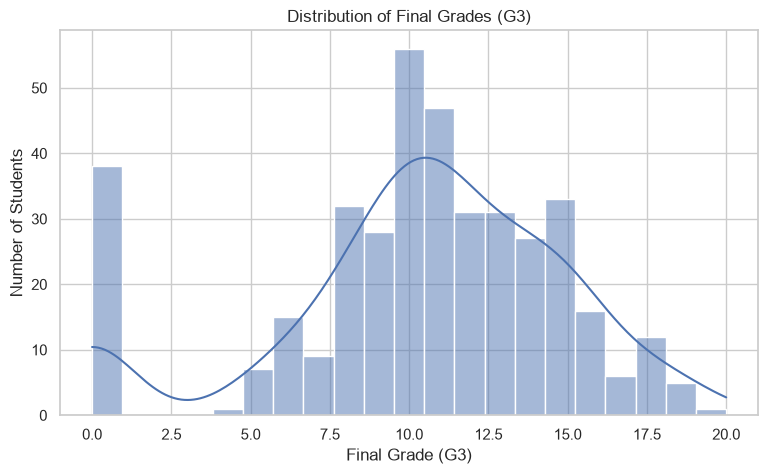

In [12]:
plt.figure(figsize=(9, 5))
sns.histplot(df["G3"], bins=21, kde=True)
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.show()

### Interpretation and modelling importance

The target distribution shows how final grades are spread across the 0–20 scale. This is important because regression models perform differently when the target is concentrated around the middle compared with when there are many extreme low or high grades.

The distribution will be considered during error analysis. If extreme grades are relatively uncommon, a model trained to minimise average error may perform well for typical students but struggle with students at the extremes.

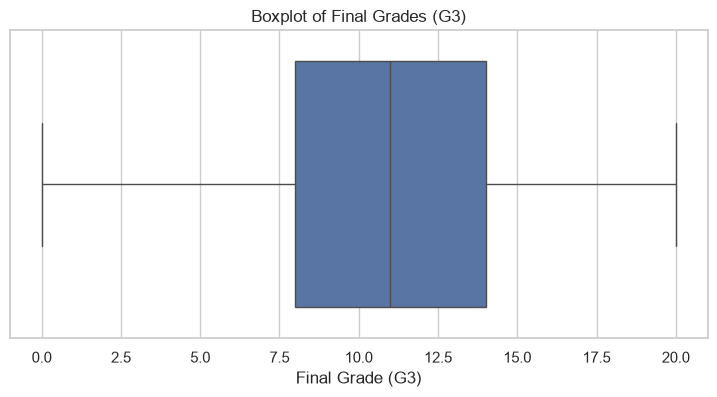

In [13]:
plt.figure(figsize=(9, 4))
sns.boxplot(x=df["G3"])
plt.title("Boxplot of Final Grades (G3)")
plt.xlabel("Final Grade (G3)")
plt.show()

### Interpretation

The boxplot provides a compact view of the median, spread and unusually low or high grades. Any points outside the boxplot whiskers are statistical observations to investigate; they are **not automatically invalid records**.

In [14]:
grade_summary = df["G3"].value_counts().sort_index().rename_axis("G3").reset_index(name="Students")
grade_summary["Percentage"] = grade_summary["Students"] / len(df) * 100
grade_summary.round(2)

,G3,Students,Percentage
0,0,38,9.62
1,4,1,0.25
2,5,7,1.77
3,6,15,3.80
4,7,9,2.28
5,8,32,8.10
6,9,28,7.09
7,10,56,14.18
8,11,47,11.90
9,12,31,7.85


### Why the grade-frequency table matters

The frequency table identifies which grade values are common and which are rare. 

### Numerical Feature Distributions

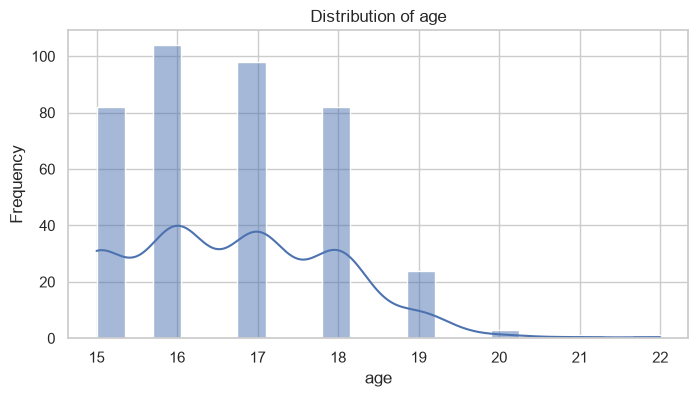

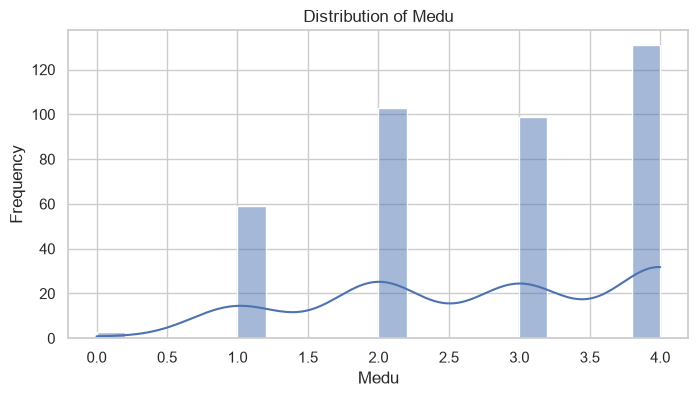

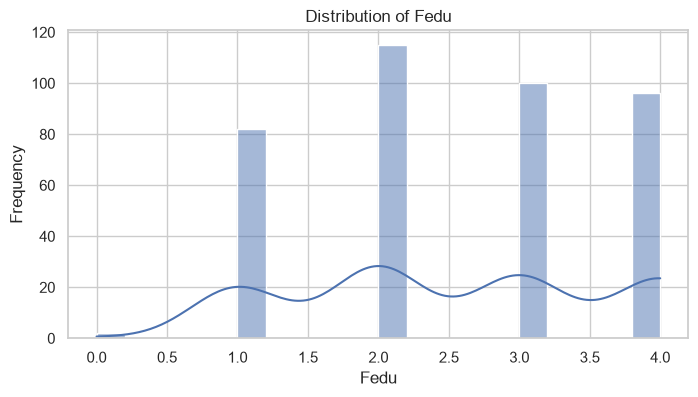

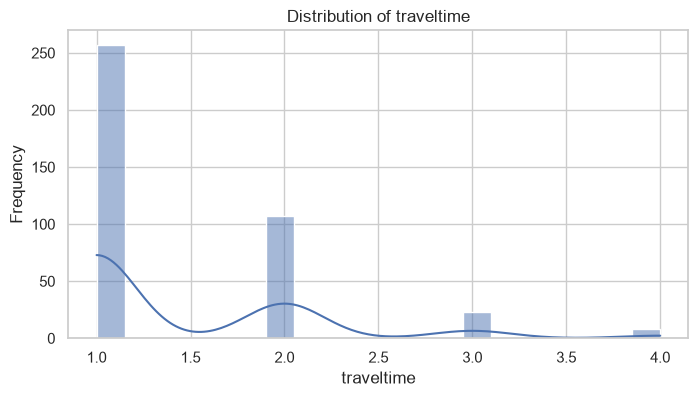

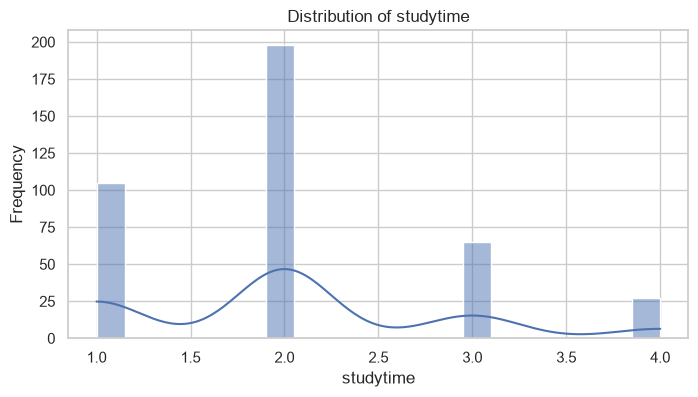

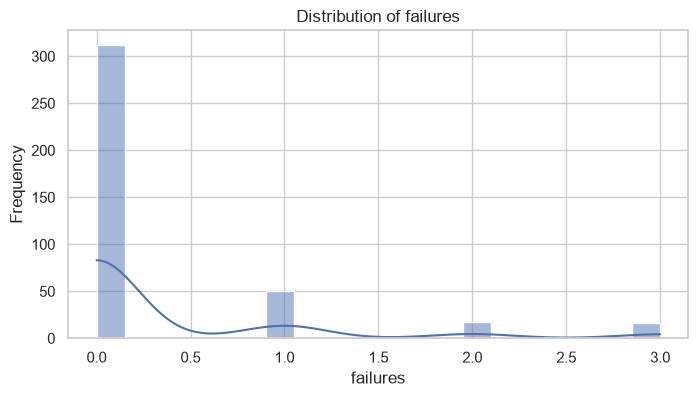

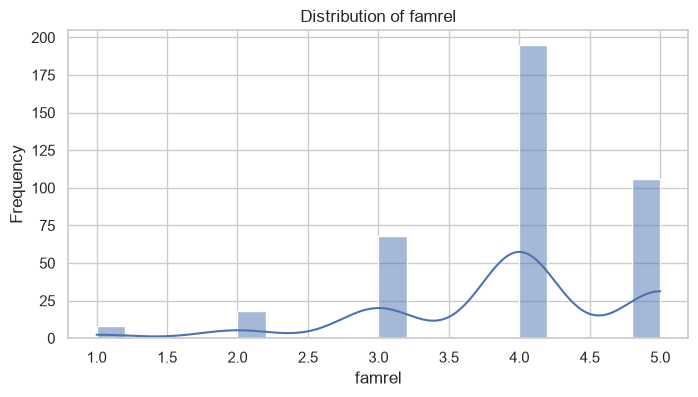

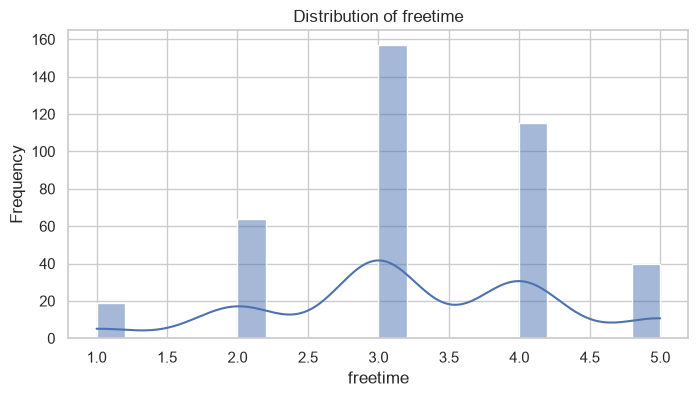

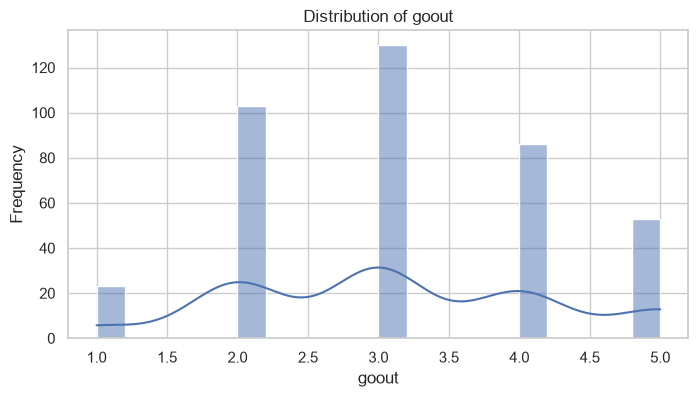

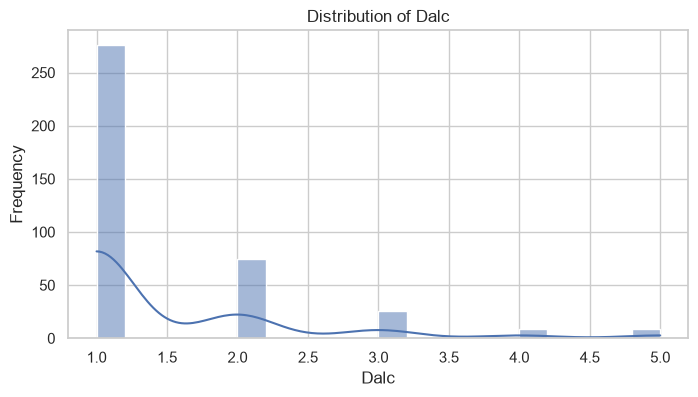

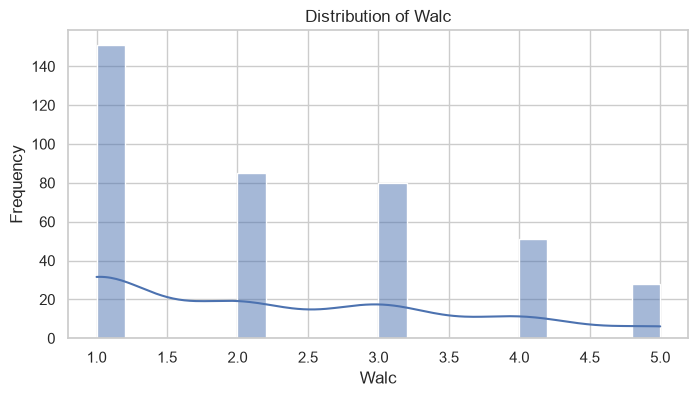

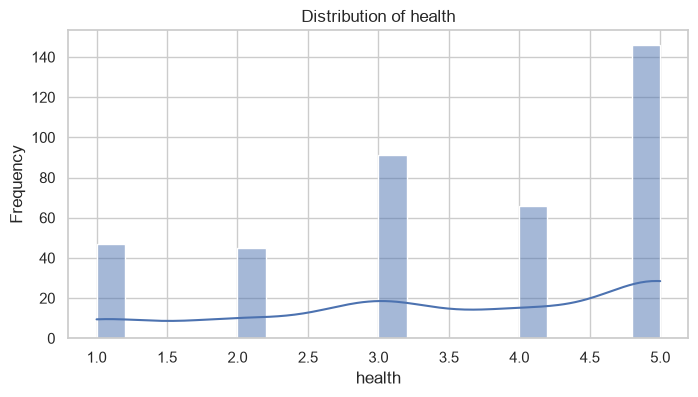

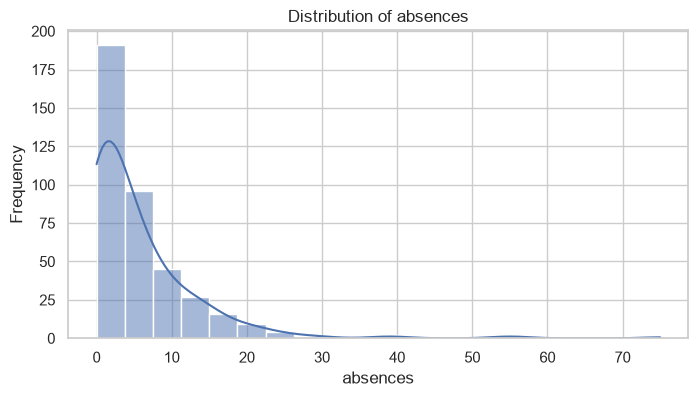

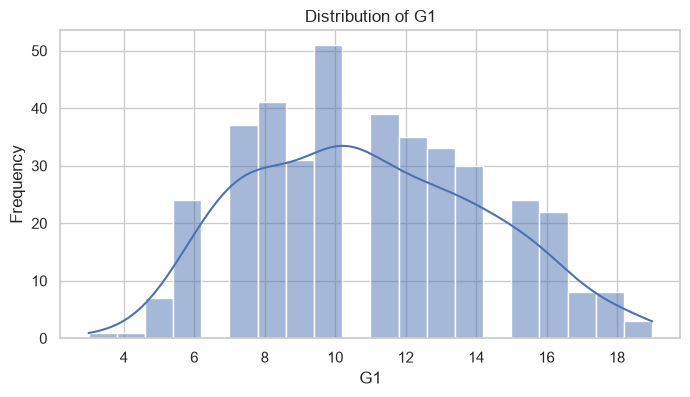

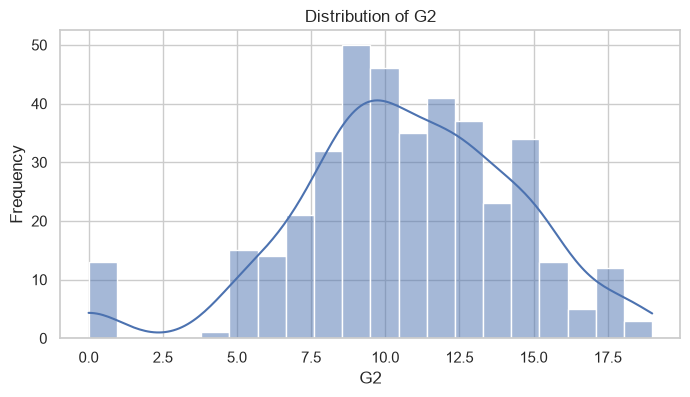

In [15]:
numeric_features_all = df.select_dtypes(include=np.number).columns.tolist()

for column in numeric_features_all:
    if column == "G3":
        continue

    plt.figure(figsize=(8, 4))
    sns.histplot(df[column], bins=20, kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

### Interpretation and modelling importance

The numerical distributions help us understand whether variables are continuous, ordinal or concentrated in a small number of categories. Many variables in this dataset are coded ordinally (for example, study time and education levels), so their numeric codes should be interpreted carefully.

These distributions are important before modelling because skewed variables and unusual values can affect distance-based models such as KNN and SVR, while tree-based models are generally less sensitive to feature scale.

### Categorical Feature Distributions

C:\Users\Nicole Kasiva\AppData\Local\Temp\ipykernel_12596\3008327847.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features_all = df.select_dtypes(include="object").columns.tolist()


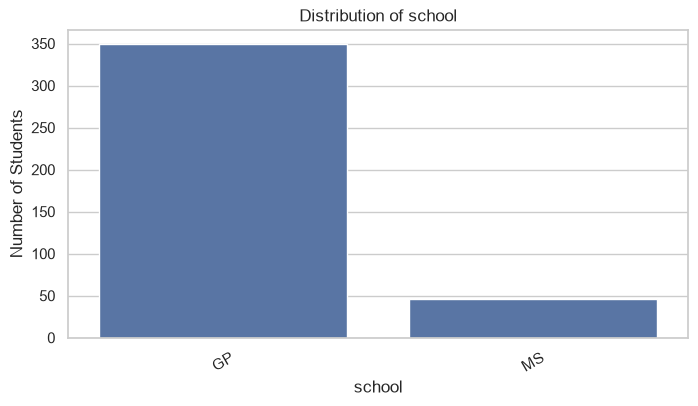

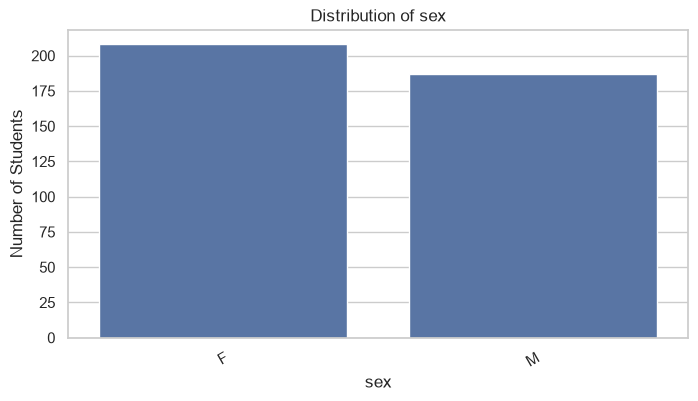

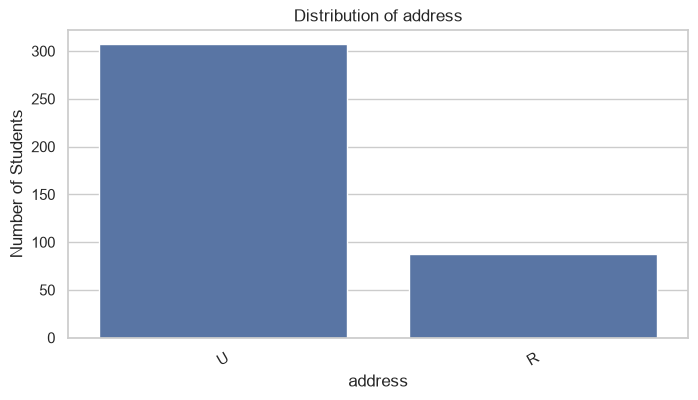

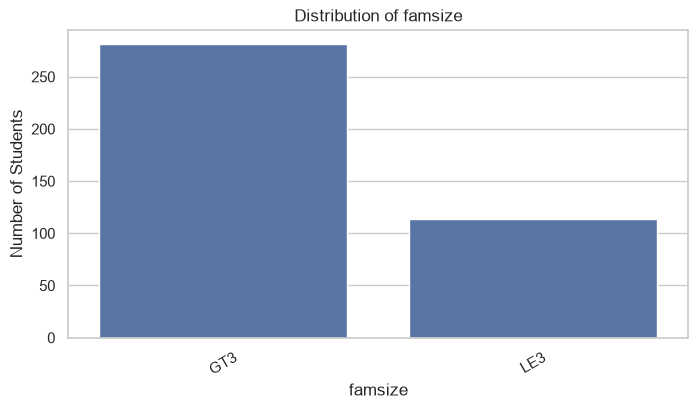

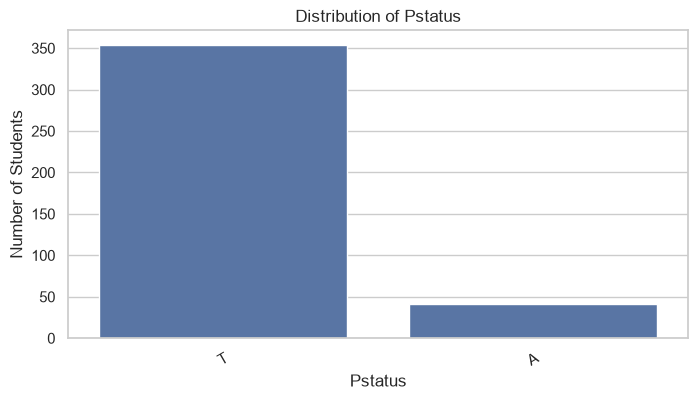

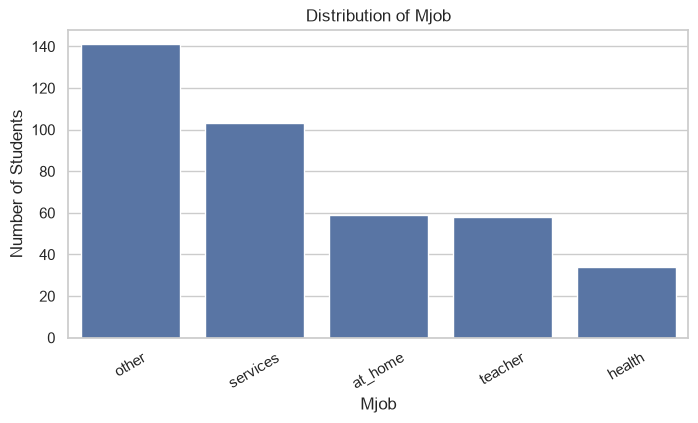

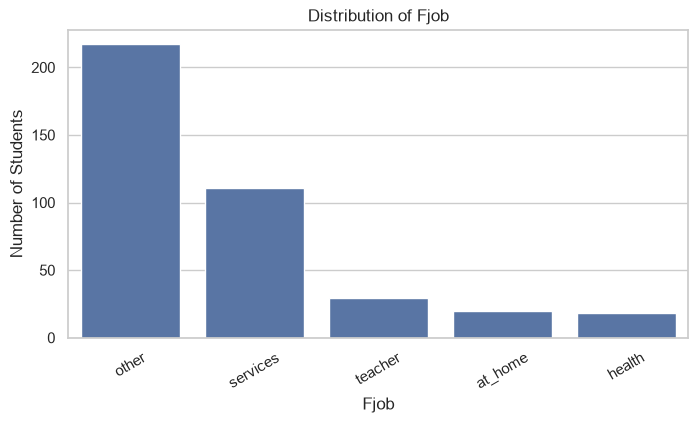

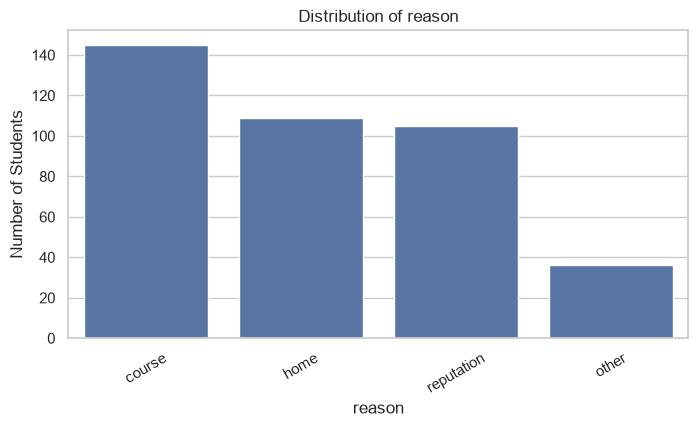

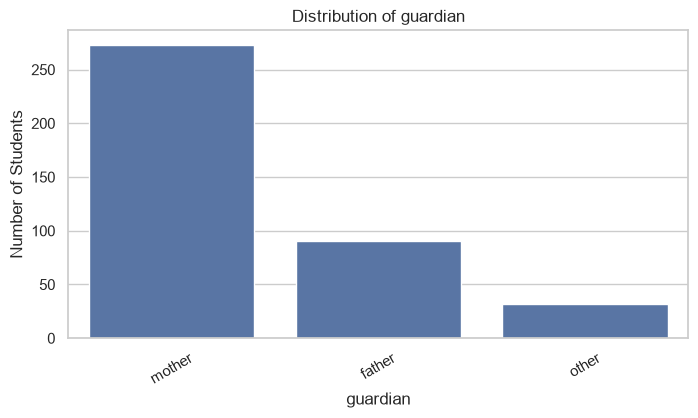

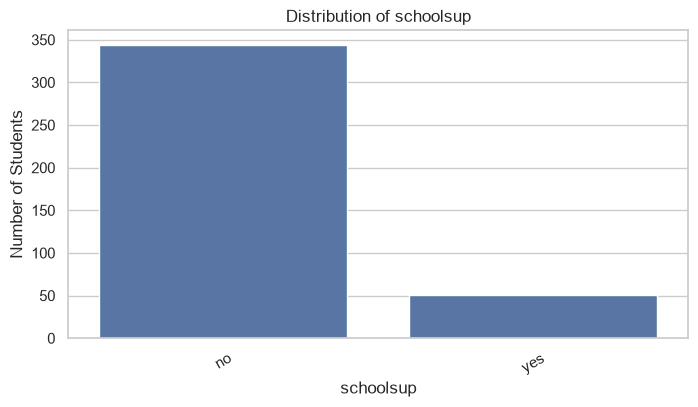

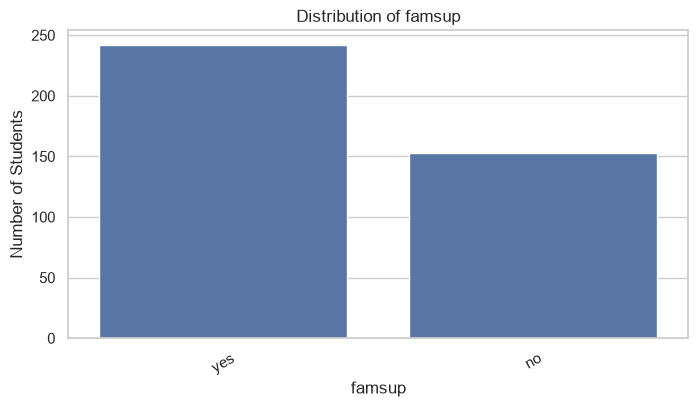

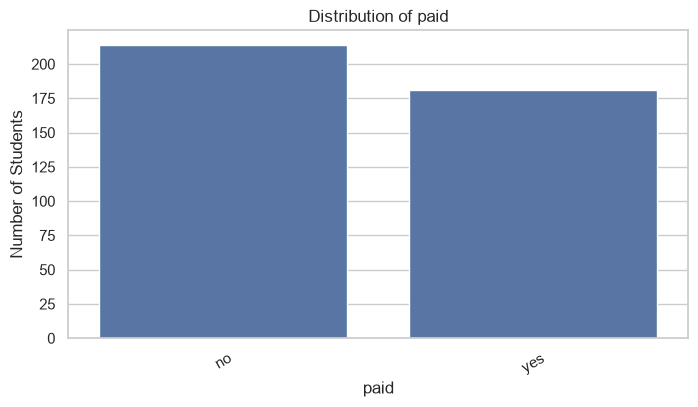

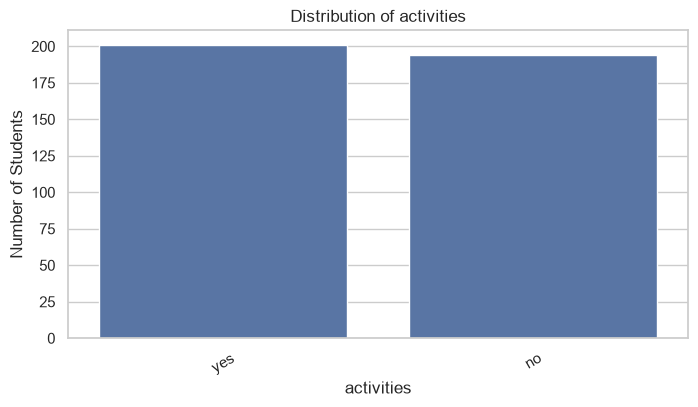

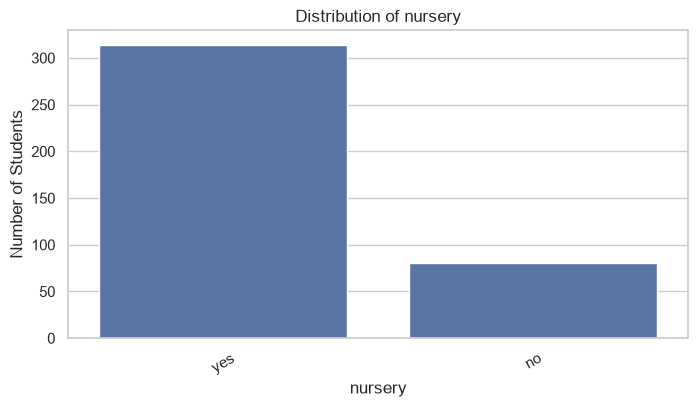

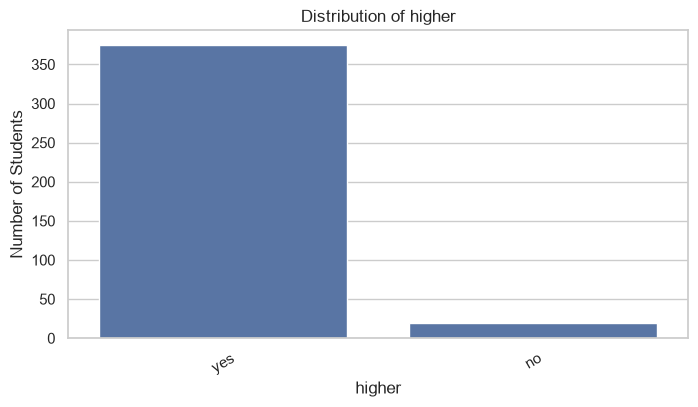

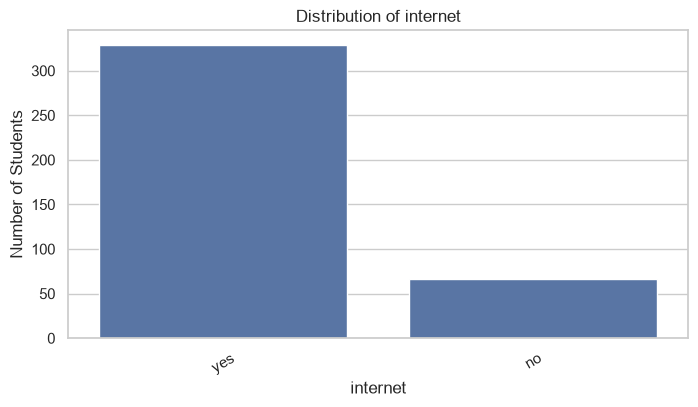

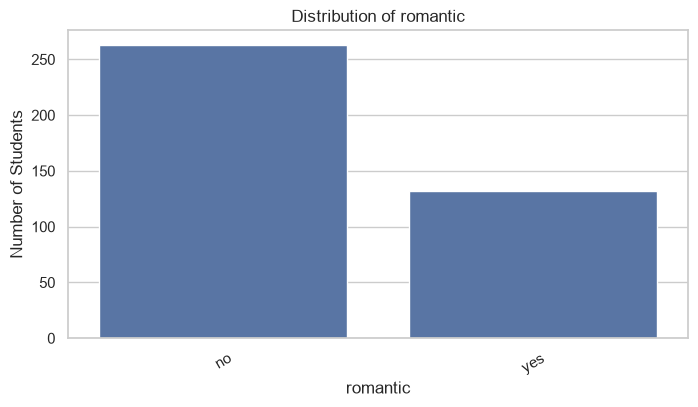

In [16]:
categorical_features_all = df.select_dtypes(include="object").columns.tolist()

for column in categorical_features_all:
    plt.figure(figsize=(8, 4))
    order = df[column].value_counts().index
    sns.countplot(data=df, x=column, order=order)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Students")
    plt.xticks(rotation=30)
    plt.show()

### Interpretation and modelling importance

Categorical distributions show whether the dataset contains balanced or highly dominant categories. This matters because a category with very few observations may be difficult for a model to learn reliably.

These variables cannot be supplied directly to most scikit-learn regression algorithms as text. They will later be transformed using **One-Hot Encoding**.

### Relationship of Numerical Features with the Target

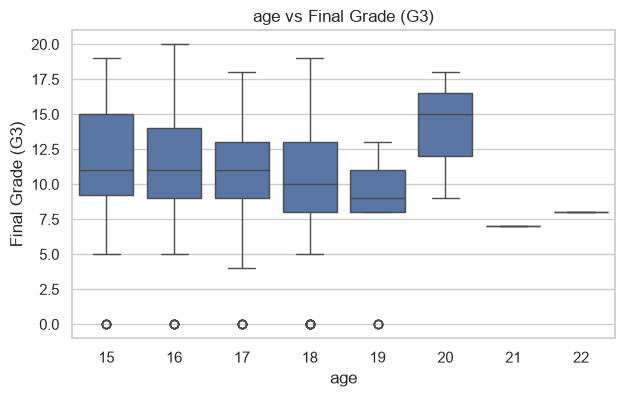

,count,mean,median
age,,,
15,82,11.26,11.0
16,104,11.03,11.0
17,98,10.28,11.0
18,82,9.55,10.0
19,24,8.21,9.0
20,3,14.00,15.0
21,1,7.00,7.0
22,1,8.00,8.0


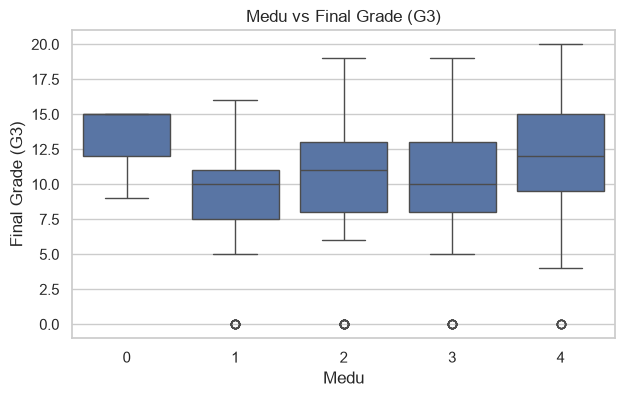

,count,mean,median
Medu,,,
0,3,13.00,15.0
1,59,8.68,10.0
2,103,9.73,11.0
3,99,10.30,10.0
4,131,11.76,12.0


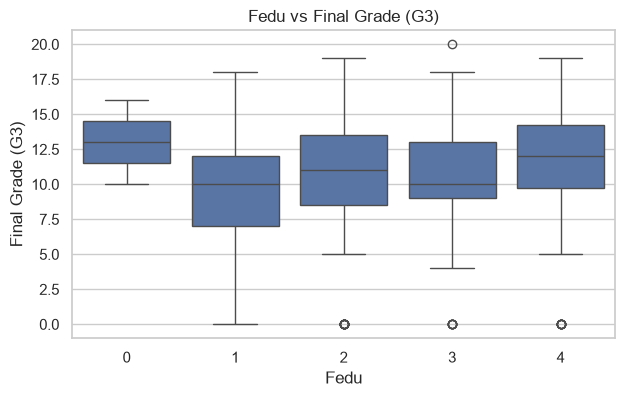

,count,mean,median
Fedu,,,
0,2,13.00,13.0
1,82,9.16,10.0
2,115,10.26,11.0
3,100,10.66,10.0
4,96,11.36,12.0


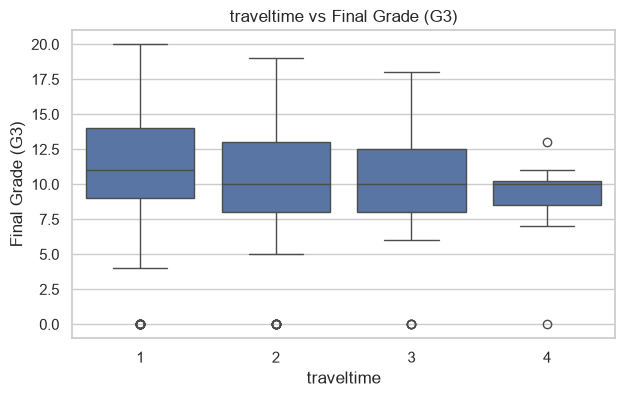

,count,mean,median
traveltime,,,
1,257,10.78,11.0
2,107,9.91,10.0
3,23,9.26,10.0
4,8,8.75,10.0


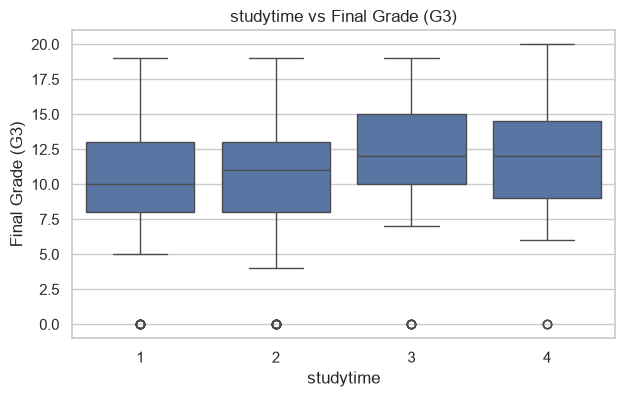

,count,mean,median
studytime,,,
1,105,10.05,10.0
2,198,10.17,11.0
3,65,11.40,12.0
4,27,11.26,12.0


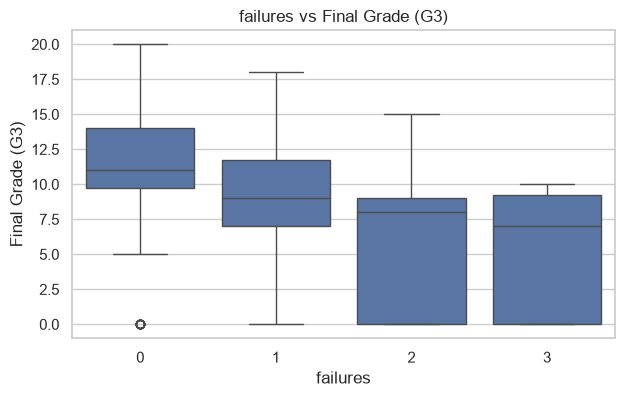

,count,mean,median
failures,,,
0,312,11.25,11.0
1,50,8.12,9.0
2,17,6.24,8.0
3,16,5.69,7.0


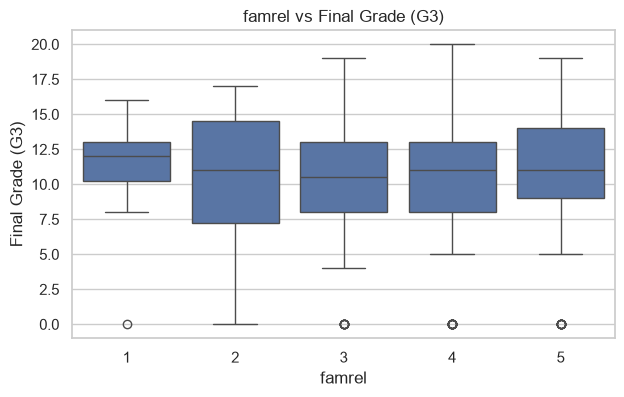

,count,mean,median
famrel,,,
1,8,10.62,12.0
2,18,9.89,11.0
3,68,10.04,10.5
4,195,10.36,11.0
5,106,10.83,11.0


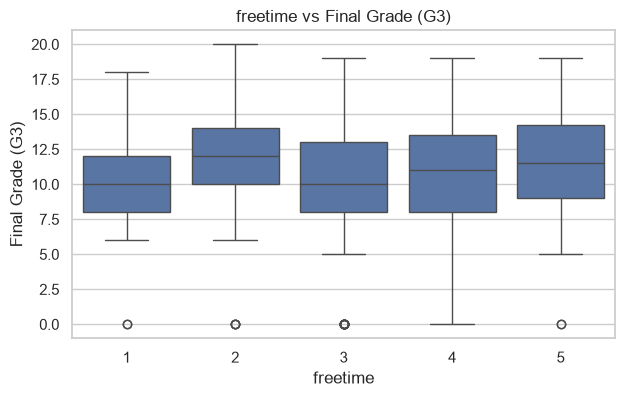

,count,mean,median
freetime,,,
1,19,9.84,10.0
2,64,11.56,12.0
3,157,9.78,10.0
4,115,10.43,11.0
5,40,11.30,11.5


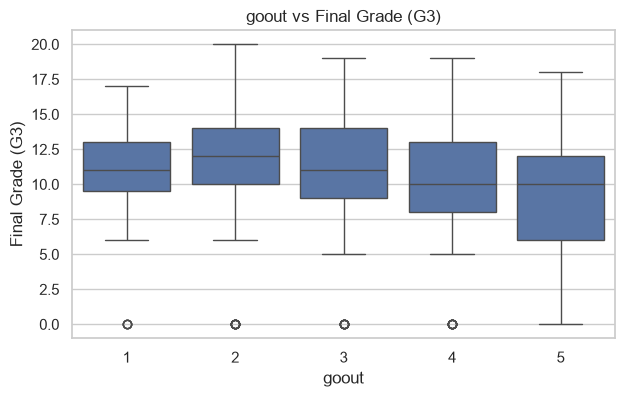

,count,mean,median
goout,,,
1,23,9.87,11.0
2,103,11.19,12.0
3,130,10.96,11.0
4,86,9.65,10.0
5,53,9.04,10.0


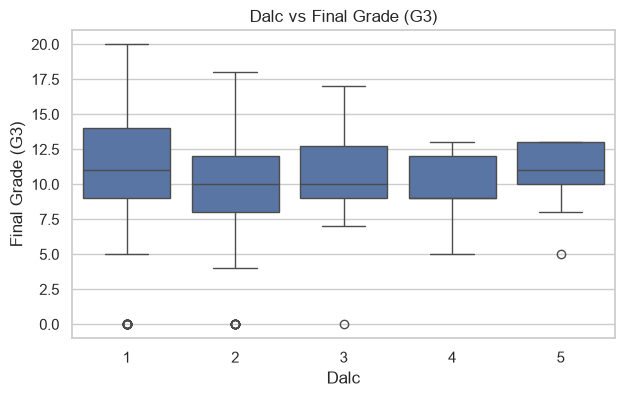

,count,mean,median
Dalc,,,
1,276,10.73,11.0
2,75,9.25,10.0
3,26,10.50,10.0
4,9,9.89,9.0
5,9,10.67,11.0


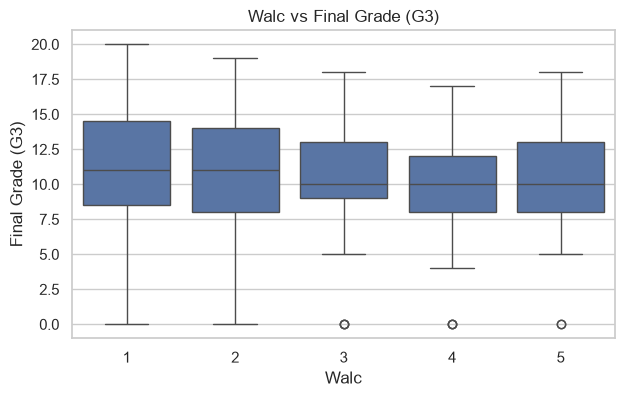

,count,mean,median
Walc,,,
1,151,10.74,11.0
2,85,10.08,11.0
3,80,10.72,10.0
4,51,9.69,10.0
5,28,10.14,10.0


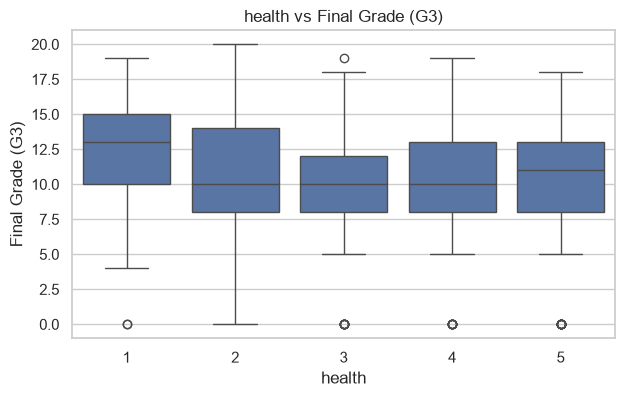

,count,mean,median
health,,,
1,47,11.87,13.0
2,45,10.22,10.0
3,91,10.01,10.0
4,66,10.11,10.0
5,146,10.40,11.0


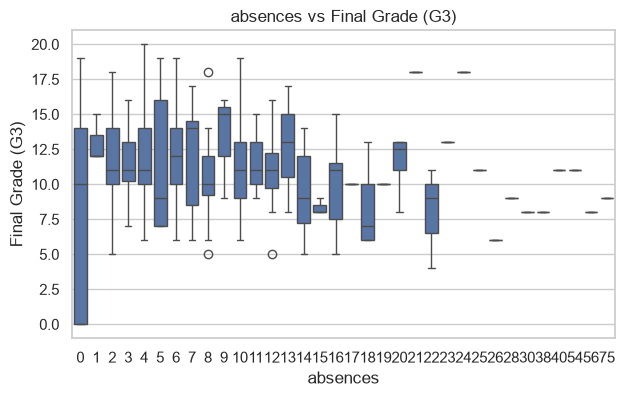

,count,mean,median
absences,,,
0,115,8.44,10.0
1,3,13.00,12.0
2,65,11.91,11.0
3,8,11.50,11.0
4,53,11.28,11.0
5,5,11.60,9.0
6,31,11.77,12.0
7,7,11.86,14.0
8,22,10.59,10.0


In [17]:
numeric_predictors_for_eda = [
    col for col in numeric_features_all
    if col not in ["G1", "G2", "G3"]
]

for column in numeric_predictors_for_eda:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x=column, y="G3")
    plt.title(f"{column} vs Final Grade (G3)")
    plt.xlabel(column)
    plt.ylabel("Final Grade (G3)")
    plt.show()

    grouped = df.groupby(column)["G3"].agg(["count", "mean", "median"]).round(2)
    display(grouped)

### Interpratation of the visuals

For each numerical predictor, we are comparing the distribution of `G3` across the feature's levels.

For example, if groups with higher study time have a higher median G3, this suggests an association between study time and final performance. If the boxes overlap substantially, the feature may have a weaker standalone relationship.

These visuals are important because the EDA helps us understand whether a feature may contain useful predictive information before we ask a model to learn the relationship. They also help identify relationships that may not be captured by a single correlation coefficient.

### Relationship of Categorical Features with the Target

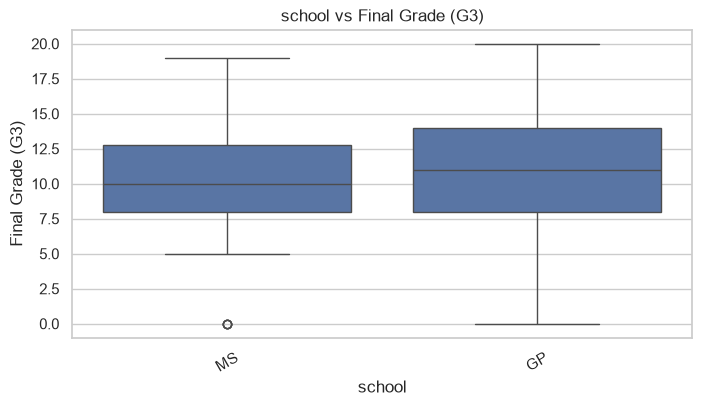

,count,mean,median
school,,,
GP,349,10.49,11.0
MS,46,9.85,10.0


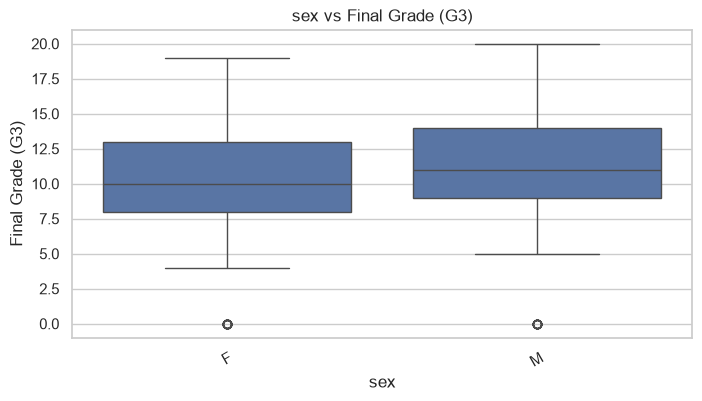

,count,mean,median
sex,,,
F,208,9.97,10.0
M,187,10.91,11.0


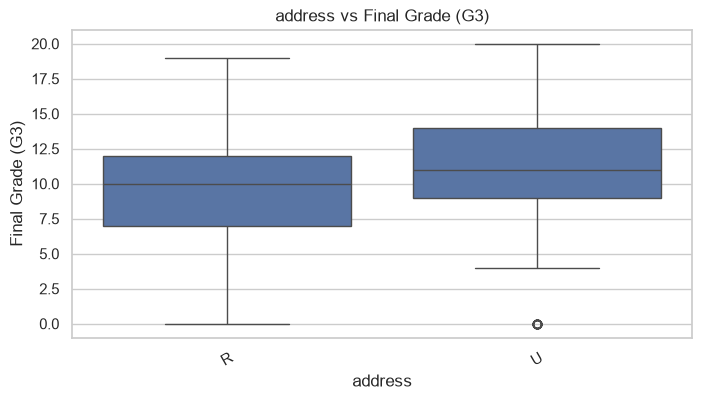

,count,mean,median
address,,,
R,88,9.51,10.0
U,307,10.67,11.0


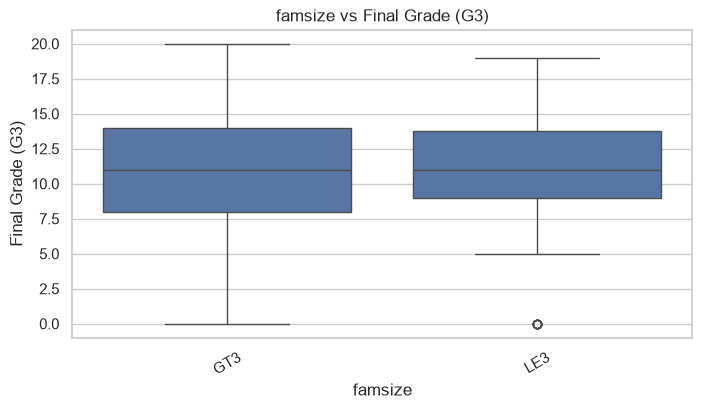

,count,mean,median
famsize,,,
GT3,281,10.18,11.0
LE3,114,11.00,11.0


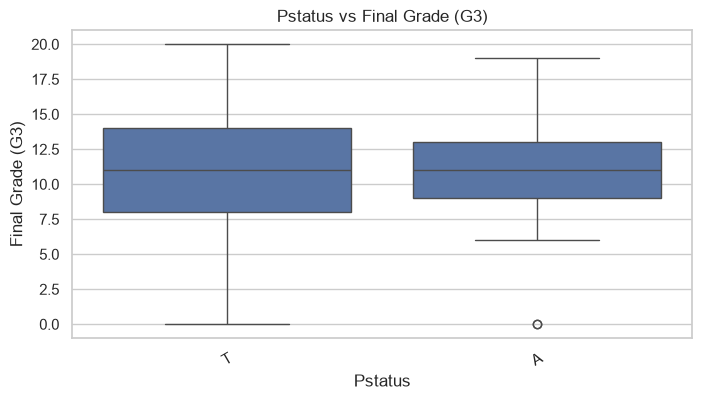

,count,mean,median
Pstatus,,,
A,41,11.20,11.0
T,354,10.32,11.0


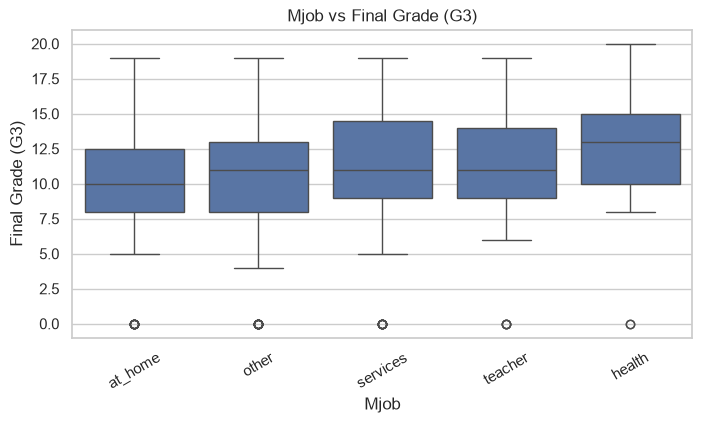

,count,mean,median
Mjob,,,
at_home,59,9.15,10.0
health,34,12.15,13.0
other,141,9.82,11.0
services,103,11.02,11.0
teacher,58,11.05,11.0


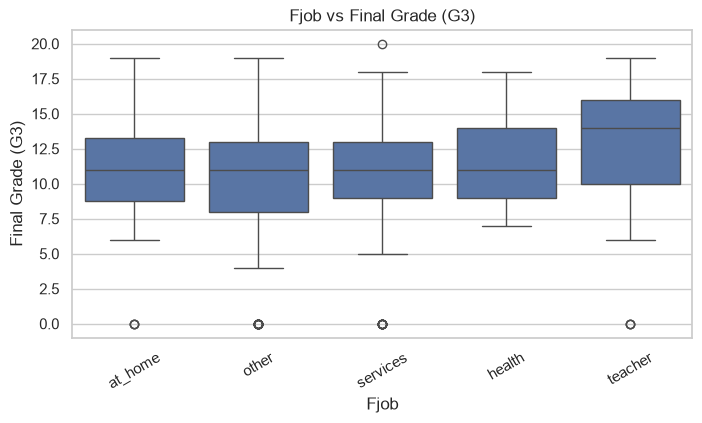

,count,mean,median
Fjob,,,
at_home,20,10.15,11.0
health,18,11.61,11.0
other,217,10.19,11.0
services,111,10.30,11.0
teacher,29,11.97,14.0


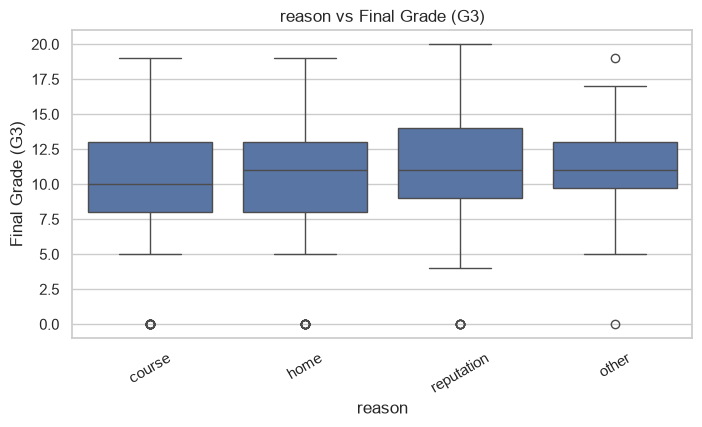

,count,mean,median
reason,,,
course,145,9.82,10.0
home,109,10.26,11.0
other,36,11.17,11.0
reputation,105,11.14,11.0


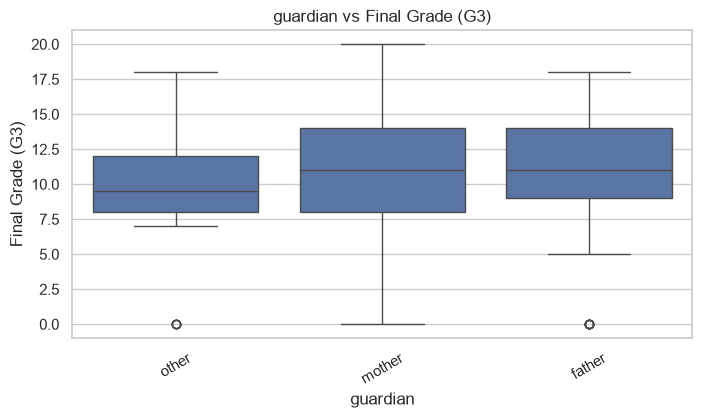

,count,mean,median
guardian,,,
father,90,10.69,11.0
mother,273,10.48,11.0
other,32,9.06,9.5


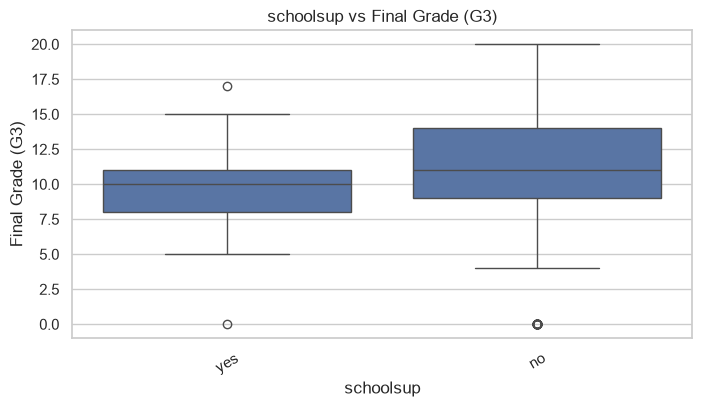

,count,mean,median
schoolsup,,,
no,344,10.56,11.0
yes,51,9.43,10.0


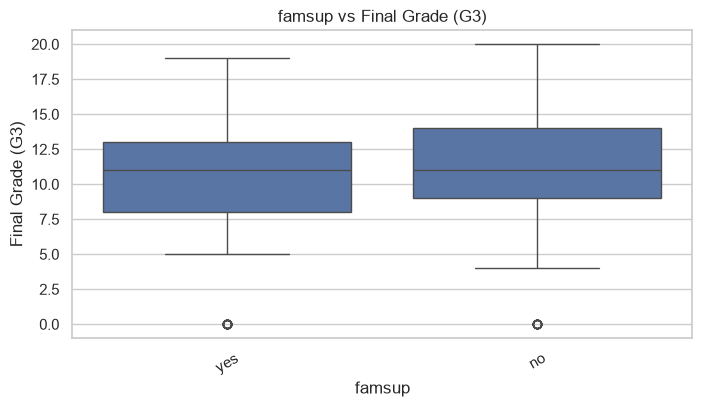

,count,mean,median
famsup,,,
no,153,10.64,11.0
yes,242,10.27,11.0


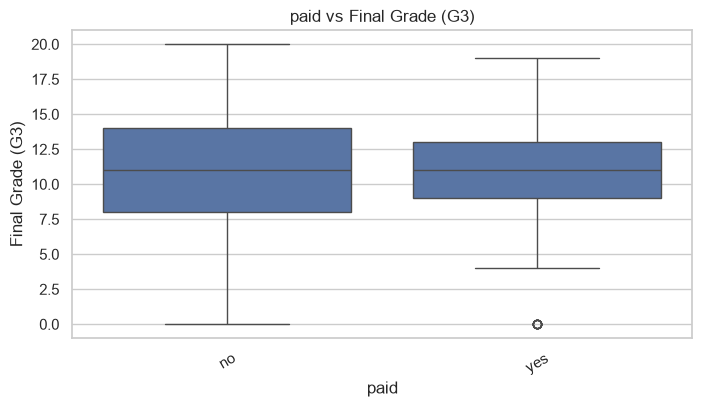

,count,mean,median
paid,,,
no,214,9.99,11.0
yes,181,10.92,11.0


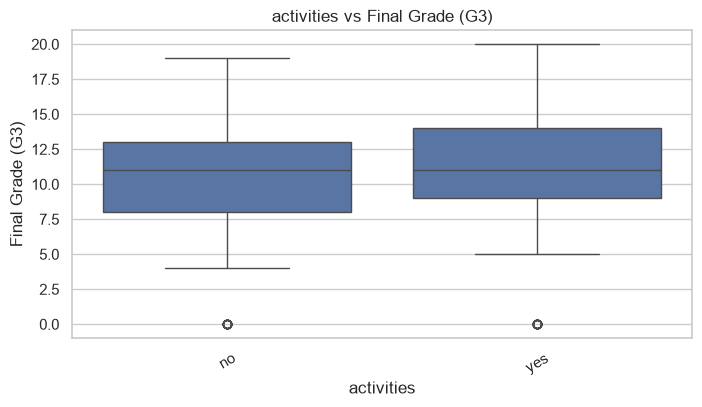

,count,mean,median
activities,,,
no,194,10.34,11.0
yes,201,10.49,11.0


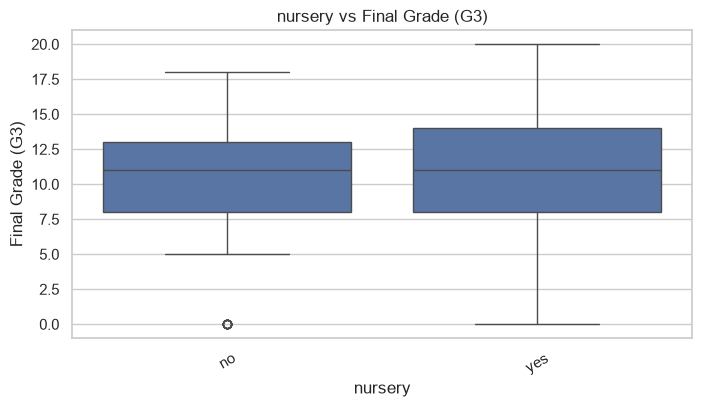

,count,mean,median
nursery,,,
no,81,9.95,11.0
yes,314,10.54,11.0


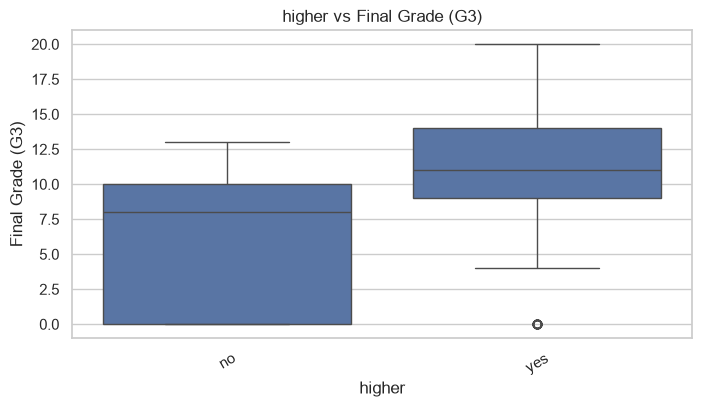

,count,mean,median
higher,,,
no,20,6.80,8.0
yes,375,10.61,11.0


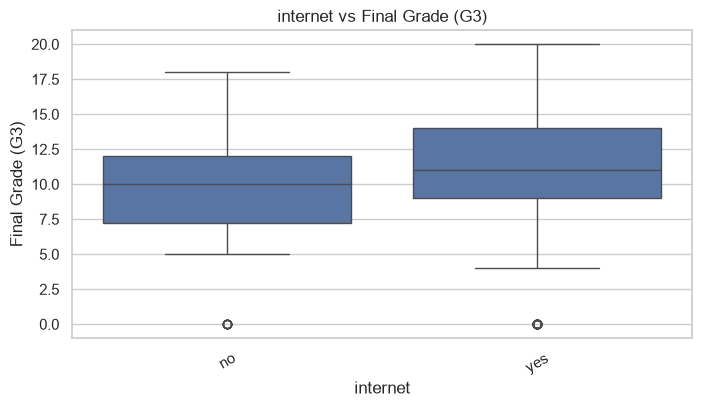

,count,mean,median
internet,,,
no,66,9.41,10.0
yes,329,10.62,11.0


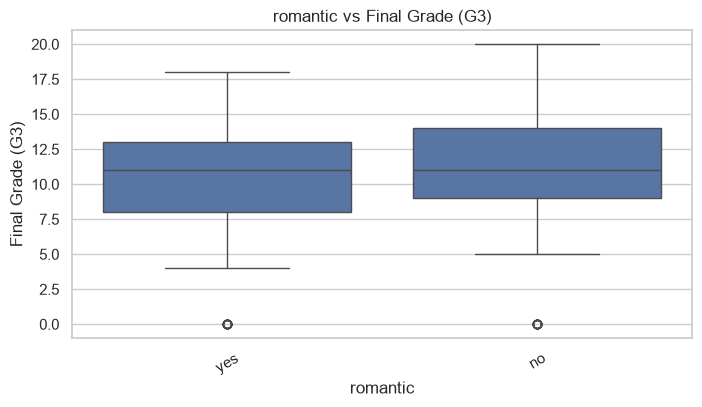

,count,mean,median
romantic,,,
no,263,10.84,11.0
yes,132,9.58,11.0


In [18]:
for column in categorical_features_all:
    plt.figure(figsize=(8, 4))
    order = df.groupby(column)["G3"].mean().sort_values().index
    sns.boxplot(data=df, x=column, y="G3", order=order)
    plt.title(f"{column} vs Final Grade (G3)")
    plt.xlabel(column)
    plt.ylabel("Final Grade (G3)")
    plt.xticks(rotation=30)
    plt.show()

    grouped = df.groupby(column)["G3"].agg(["count", "mean", "median"]).round(2)
    display(grouped)

### Interpretation and modelling importance

These plots show whether students in different categories have different grade distributions. The emphasis is on **patterns and overlap**, not simply which category has the highest mean.

A categorical variable can still be useful even when the group means are close, because it may interact with other predictors. The visualisations therefore guide model building rather than acting as proof that a feature causes academic performance.

### Investigate the Leakage Variables During EDA

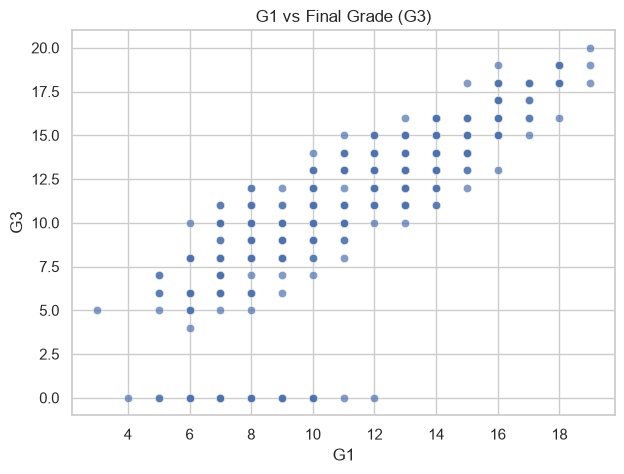

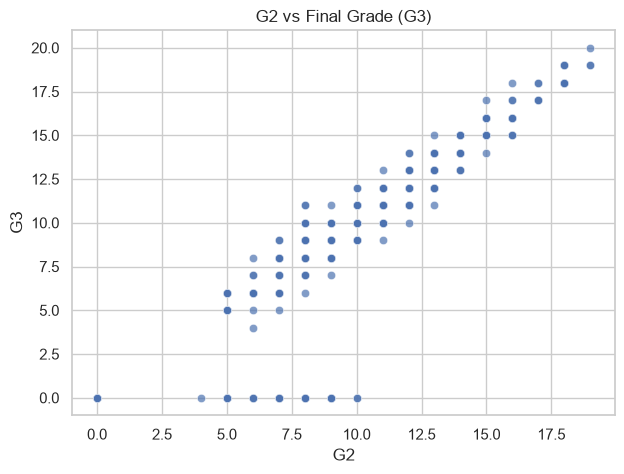

Correlation G1-G3: 0.801
Correlation G2-G3: 0.905


In [19]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="G1", y="G3", alpha=0.7)
plt.title("G1 vs Final Grade (G3)")
plt.xlabel("G1")
plt.ylabel("G3")
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="G2", y="G3", alpha=0.7)
plt.title("G2 vs Final Grade (G3)")
plt.xlabel("G2")
plt.ylabel("G3")
plt.show()

print("Correlation G1-G3:", round(df["G1"].corr(df["G3"]), 3))
print("Correlation G2-G3:", round(df["G2"].corr(df["G3"]), 3))

### Interpretation and leakage decision

These visuals are deliberately included to demonstrate why `G1` and `G2` need special treatment. Their relationship with `G3` is expected to be much stronger than many background characteristics because they are earlier academic grades.

Although including them could improve predictive accuracy, doing so would change the project question from **early identification using student characteristics** to **predicting the final grade from earlier grades**.

Therefore, `G1` and `G2` are excluded from the main model.

### Additional EDA: Behavioural and Academic Factors

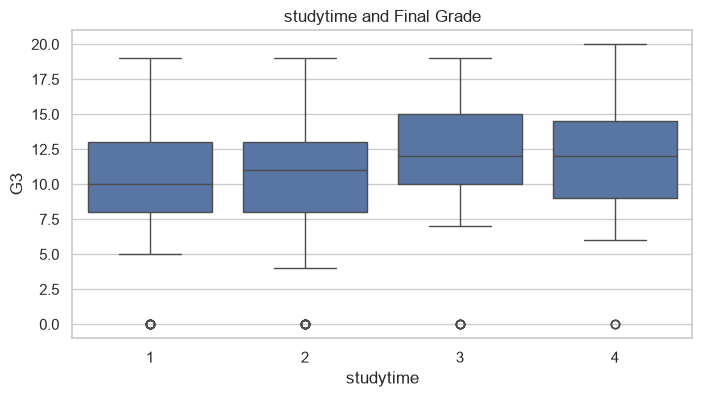

,count,mean,median
studytime,,,
1,105,10.05,10.0
2,198,10.17,11.0
3,65,11.40,12.0
4,27,11.26,12.0


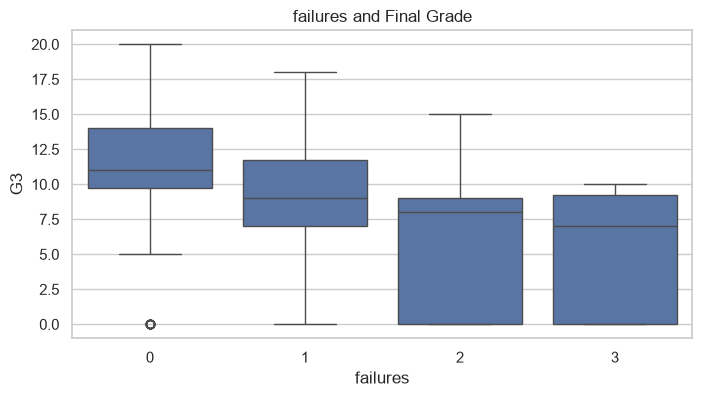

,count,mean,median
failures,,,
0,312,11.25,11.0
1,50,8.12,9.0
2,17,6.24,8.0
3,16,5.69,7.0


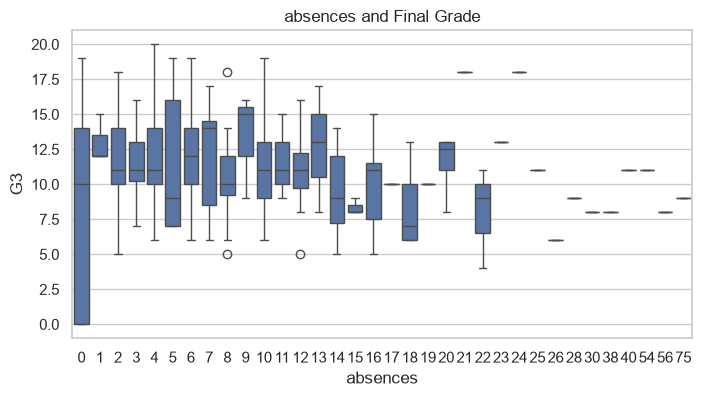

,count,mean,median
absences,,,
0,115,8.44,10.0
1,3,13.00,12.0
2,65,11.91,11.0
3,8,11.50,11.0
4,53,11.28,11.0
5,5,11.60,9.0
6,31,11.77,12.0
7,7,11.86,14.0
8,22,10.59,10.0


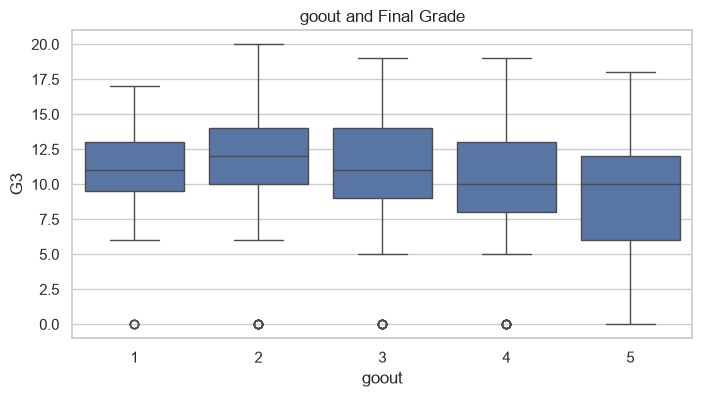

,count,mean,median
goout,,,
1,23,9.87,11.0
2,103,11.19,12.0
3,130,10.96,11.0
4,86,9.65,10.0
5,53,9.04,10.0


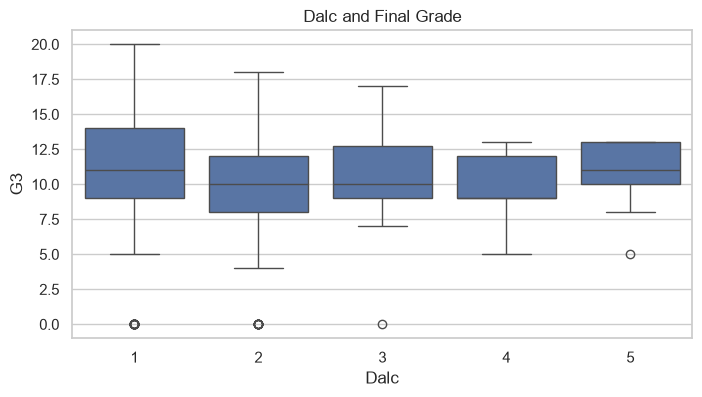

,count,mean,median
Dalc,,,
1,276,10.73,11.0
2,75,9.25,10.0
3,26,10.50,10.0
4,9,9.89,9.0
5,9,10.67,11.0


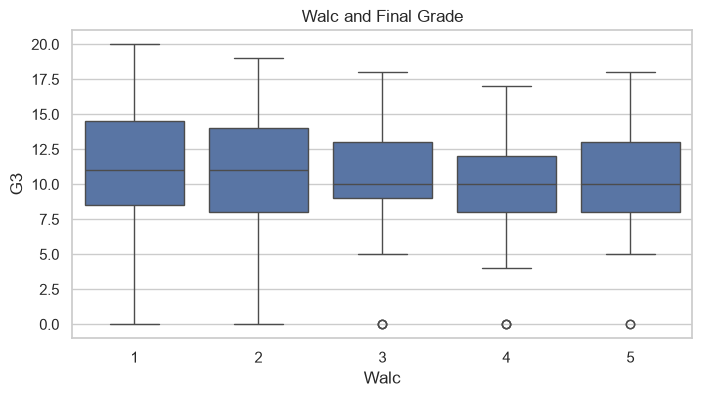

,count,mean,median
Walc,,,
1,151,10.74,11.0
2,85,10.08,11.0
3,80,10.72,10.0
4,51,9.69,10.0
5,28,10.14,10.0


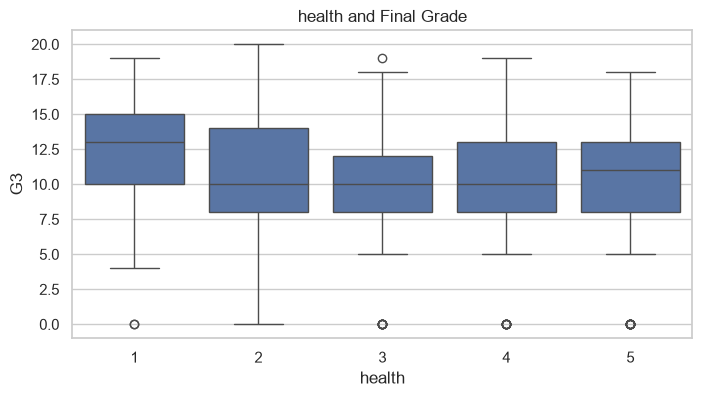

,count,mean,median
health,,,
1,47,11.87,13.0
2,45,10.22,10.0
3,91,10.01,10.0
4,66,10.11,10.0
5,146,10.40,11.0


In [20]:
eda_features = ["studytime", "failures", "absences", "goout", "Dalc", "Walc", "health"]

for feature in eda_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=feature, y="G3")
    plt.title(f"{feature} and Final Grade")
    plt.xlabel(feature)
    plt.ylabel("G3")
    plt.show()

    display(
        df.groupby(feature)["G3"]
          .agg(["count", "mean", "median"])
          .round(2)
    )

### EDA findings to look for

The behavioural variables are particularly relevant because they describe study habits, previous failures, absences, social activity, alcohol consumption and health.

The grouped tables immediately below each visual should be used to support the interpretation. 
This section is useful for modelling because it identifies potentially informative predictors and helps explain why the model may later perform differently for different types of students.

## 17. Correlation Analysis

In [ ]:
correlation_columns = numeric_predictors_for_eda + ["G1", "G2", "G3"]
correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

### Why correlation matters

Correlation measures the strength and direction of a linear relationship between numerical variables.

It is useful here for two reasons:

1. It helps identify numerical features that are associated with `G3`.
2. It helps identify predictors that are strongly related to each other, which can create **multicollinearity**.

Correlation does not prove causation and only captures linear association.

In [ ]:
g3_correlations = (
    df[correlation_columns]
      .corr()["G3"]
      .drop("G3")
      .sort_values()
)

plt.figure(figsize=(9, 7))
g3_correlations.plot(kind="barh")
plt.title("Correlation of Numerical Variables with Final Grade (G3)")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.show()

display(g3_correlations.sort_values(ascending=False).round(3))

### Interpretation of correlation with the target

Features with larger absolute correlations have stronger linear relationships with `G3`, while values close to zero indicate weak linear relationships.

The important modelling point is that a weak correlation does **not** automatically mean a feature is useless. A feature may contribute through non-linear relationships or in combination with other variables. Conversely, a strong correlation does not mean the relationship is causal.

`G1` and `G2` are treated separately because their strong relationship with `G3` is one reason they are excluded from the predictive feature set.

## 18. Multicollinearity: Predictor-to-Predictor Correlation

In [ ]:
predictor_numeric = df[predictor_features].select_dtypes(include=np.number).columns.tolist()

predictor_corr = df[predictor_numeric].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    predictor_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix of Numerical Predictors Used for Modelling")
plt.show()

In [ ]:
# Identify potentially strong predictor-to-predictor correlations
pairs = []

for i, col1 in enumerate(predictor_numeric):
    for col2 in predictor_numeric[i+1:]:
        corr = predictor_corr.loc[col1, col2]
        if abs(corr) >= 0.70:
            pairs.append({
                "Feature 1": col1,
                "Feature 2": col2,
                "Correlation": corr
            })

strong_corr_pairs = pd.DataFrame(pairs).sort_values(
    "Correlation",
    key=lambda s: s.abs(),
    ascending=False
)

strong_corr_pairs

### Effect of multicollinearity on modelling

Multicollinearity occurs when predictors contain overlapping information.

For ordinary linear regression, high multicollinearity can:

- make coefficient estimates unstable;
- inflate standard errors;
- make coefficient interpretation difficult;
- cause coefficients to change substantially when predictors are added or removed.

It is less damaging to many tree-based models, but it can still make interpretation harder and can affect some distance- or coefficient-based models.

The correlation matrix is therefore a first diagnostic, while **VIF** gives us a more formal multicollinearity check.

## 19. VIF Analysis Before Feature Selection

In [ ]:
def calculate_vif(dataframe):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = dataframe.columns
    vif_data["VIF"] = [
        variance_inflation_factor(dataframe.values, i)
        for i in range(dataframe.shape[1])
    ]
    return vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

vif_input = df[predictor_numeric].astype(float).copy()
vif_table = calculate_vif(vif_input)

vif_table.round(3)

### How VIF is interpreted

Variance Inflation Factor (VIF) measures how much the variance of a regression coefficient is inflated because a predictor can be explained by the other predictors.

A common rule of thumb is:

- **VIF ≈ 1:** little evidence of multicollinearity.
- **VIF between 1 and 5:** usually acceptable.
- **VIF above 5:** potentially concerning.
- **VIF above 10:** commonly treated as strong multicollinearity.

VIF is being applied here to the **numerical predictors** because the original categorical variables are text categories and are not directly suitable for this calculation. The categorical predictors remain available for modelling and are handled later through one-hot encoding.

## 20. VIF-Based Numerical Feature Selection

In [ ]:
# Iteratively remove the numerical predictor with the highest VIF
# until all remaining VIF values are <= 5.

vif_features = predictor_numeric.copy()
vif_history = []

while len(vif_features) > 1:
    current_vif = calculate_vif(df[vif_features].astype(float))
    max_vif = current_vif.loc[0, "VIF"]
    max_feature = current_vif.loc[0, "Feature"]

    vif_history.append({
        "Feature_Checked": max_feature,
        "VIF": max_vif,
        "Action": "Remove" if max_vif > 5 else "Stop"
    })

    if max_vif <= 5:
        break

    vif_features.remove(max_feature)

selected_numeric_features = vif_features

print("Original numerical predictors:", predictor_numeric)
print("\nSelected numerical predictors:", selected_numeric_features)
print("\nRemoved numerical predictors:", sorted(set(predictor_numeric) - set(selected_numeric_features)))

print("\nVIF selection history:")
display(pd.DataFrame(vif_history).round(3))

print("\nFinal VIF table:")
display(calculate_vif(df[selected_numeric_features].astype(float)).round(3))

### Feature-selection decision

VIF is used as a **multicollinearity-based selection method**, not as a measure of whether a variable is important to academic performance.

The selected model retains all categorical predictors and only removes numerical predictors that show excessive redundancy according to the VIF threshold.

We will therefore compare:

1. **All non-leakage predictors**, and
2. **VIF-selected numerical predictors + all categorical predictors**.

This comparison tests whether removing redundant numerical variables improves generalisation.

## 21. Create the Full and VIF-Selected Feature Sets

In [ ]:
categorical_features = X_all.select_dtypes(include="object").columns.tolist()

selected_features = selected_numeric_features + categorical_features

X_selected = df[selected_features].copy()

print("Full feature set size:", X_all.shape[1])
print("VIF-selected feature set size:", X_selected.shape[1])
print("Number of categorical predictors retained:", len(categorical_features))
print("Categorical predictors:")
print(categorical_features)

## 22. Train-Test Split

The test set is kept separate until final evaluation. The preprocessing steps are fitted inside pipelines using only the training data.

In [ ]:
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all,
    y,
    test_size=0.20,
    random_state=42
)

X_train_selected = X_train_all[selected_features].copy()
X_test_selected = X_test_all[selected_features].copy()

print("Training observations:", X_train_all.shape[0])
print("Testing observations:", X_test_all.shape[0])

## 23. Preprocessing: Encoding and Scaling

In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            drop="first",
            sparse_output=False
        ))
    ]
)

preprocessor_all = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, predictor_numeric),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor_selected = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, selected_numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Numerical variables scaled:", predictor_numeric)
print("\nCategorical variables one-hot encoded:")
print(categorical_features)

### Why StandardScaler?

`StandardScaler` transforms numerical variables so that they have approximately mean 0 and standard deviation 1.

This is particularly important for:

- **KNN**, where distance is central to prediction;
- **SVR**, where feature scale influences the optimisation;
- **Linear/Ridge/Lasso models**, where comparable scales make regularisation behave more consistently.

Tree-based models do not require scaling in principle, but using a common preprocessing pipeline allows us to compare models consistently without changing the raw dataset.

### Why One-Hot Encoding?

The categorical variables contain labels such as `sex`, `school`, `Mjob`, `guardian`, `higher` and `internet`. One-Hot Encoding converts these categories into numerical indicator variables that regression algorithms can use.

`drop="first"` removes one category from each categorical variable to avoid perfect linear dependence among the dummy variables.

## 24. Evaluation Metrics

In [ ]:
def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R²": r2_score(y_true, y_pred)
    }

### Which metric is most useful for this project?

**MAE (Mean Absolute Error)** is especially intuitive here because the target is a grade measured from **0 to 20**.

For example, an MAE of 3 means that predictions are, on average, about **3 grade points away from the actual final grade**.

RMSE is also important because it penalises large errors more heavily than MAE. This is useful when a model makes very poor predictions for a small number of students.

R² describes the proportion of variation in `G3` explained by the model relative to a baseline that predicts the mean grade. It is useful for model comparison but should not be interpreted as an error in grade points.

For this project, **MAE and RMSE will be prioritised for practical prediction accuracy**, while R² provides complementary information.

## 25. Regression Models and Why They Were Chosen

### Linear Regression
Provides a simple baseline and assumes an approximately linear relationship between predictors and the target.

### Ridge Regression
A linear regression model with L2 regularisation. It shrinks coefficients and can reduce instability caused by correlated predictors or an overly flexible linear model.

### Lasso Regression
Uses L1 regularisation. It can shrink some coefficients to zero, providing a form of embedded feature selection and helping control model complexity.

### Polynomial Regression
Extends linear regression by adding polynomial terms. It is used to investigate whether non-linear relationships improve performance.

### Decision Tree Regressor
Learns non-linear rules and interactions between variables without requiring a linear relationship.

### Random Forest Regressor
Combines many decision trees and averages their predictions, usually producing a more stable tree-based model than one tree.

### Gradient Boosting Regressor
Builds trees sequentially, with later trees focusing on previous errors. It is included as another strong non-linear tree-based method.

### KNN Regressor
Predicts from nearby observations. Scaling is important because distance determines which observations are considered neighbours.

### SVR
Support Vector Regression can model non-linear relationships, especially with the RBF kernel. It is sensitive to feature scaling, making the preprocessing pipeline important.

## 26. Build Models Using the Full Non-Leakage Feature Set

In [ ]:
models_all = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01, max_iter=10000),
    "Polynomial Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR(kernel="rbf")
}

In [ ]:
pipelines_all = {}

for name, model in models_all.items():
    if name == "Polynomial Regression":
        pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor_all),
                ("polynomial_features", PolynomialFeatures(degree=2, include_bias=False)),
                ("model", model)
            ]
        )
    else:
        pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor_all),
                ("model", model)
            ]
        )

    pipelines_all[name] = pipeline

In [ ]:
results_all = []

predictions_all = {}

for name, pipeline in pipelines_all.items():
    pipeline.fit(X_train_all, y_train)
    predictions = pipeline.predict(X_test_all)
    predictions_all[name] = predictions

    metrics = evaluate_model(y_test, predictions)
    metrics["Model"] = name
    results_all.append(metrics)

results_all = pd.DataFrame(results_all).set_index("Model")
results_all.sort_values("RMSE")

### Model comparison before tuning — full feature set

Lower **MAE**, **MSE** and **RMSE** indicate smaller prediction errors. Higher **R²** indicates that the model explains more variation in the target.

The model with the lowest MAE is particularly easy to interpret in this project because the error is measured directly in final-grade points.

Do not select a final model using R² alone. A model can have a relatively high R² while still making errors that are large in the context of a 0–20 grade scale.

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_all.reset_index(),
    x="Model",
    y="MAE"
)
plt.title("Model Comparison Using MAE — Full Feature Set")
plt.xlabel("Model")
plt.ylabel("MAE (grade points)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_all.reset_index(),
    x="Model",
    y="RMSE"
)
plt.title("Model Comparison Using RMSE — Full Feature Set")
plt.xlabel("Model")
plt.ylabel("RMSE (grade points)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_all.reset_index(),
    x="Model",
    y="R²"
)
plt.title("Model Comparison Using R² — Full Feature Set")
plt.xlabel("Model")
plt.ylabel("R²")
plt.xticks(rotation=45)
plt.show()

## 27. Full Feature Set: Automatically Identify the Best Pre-Tuning Models

In [ ]:
best_by_mae = results_all["MAE"].idxmin()
best_by_rmse = results_all["RMSE"].idxmin()
best_by_r2 = results_all["R²"].idxmax()

print("Best model by MAE:", best_by_mae)
print("Best model by RMSE:", best_by_rmse)
print("Best model by R²:", best_by_r2)

### Interpretation

The best pre-tuning model should be selected using a combination of practical error and generalisation metrics. MAE is particularly important because it tells us the typical prediction error in grade points, while RMSE highlights whether the model has serious large-error cases.

If the same model performs best across MAE, RMSE and R², the choice is straightforward. If the metrics disagree, the final decision should consider the size of the errors, residual behaviour and model complexity.

## 28. Compare Full Features Against the VIF-Selected Features

In [ ]:
pipelines_selected = {}

for name, model in models_all.items():
    if name == "Polynomial Regression":
        pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor_selected),
                ("polynomial_features", PolynomialFeatures(degree=2, include_bias=False)),
                ("model", model)
            ]
        )
    else:
        pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor_selected),
                ("model", model)
            ]
        )

    pipelines_selected[name] = pipeline

In [ ]:
results_selected = []
predictions_selected = {}

for name, pipeline in pipelines_selected.items():
    pipeline.fit(X_train_selected, y_train)
    predictions = pipeline.predict(X_test_selected)
    predictions_selected[name] = predictions

    metrics = evaluate_model(y_test, predictions)
    metrics["Model"] = name
    results_selected.append(metrics)

results_selected = pd.DataFrame(results_selected).set_index("Model")

comparison_mae = pd.DataFrame({
    "All Features": results_all["MAE"],
    "VIF-Selected Features": results_selected["MAE"]
})

comparison_rmse = pd.DataFrame({
    "All Features": results_all["RMSE"],
    "VIF-Selected Features": results_selected["RMSE"]
})

display(comparison_mae.round(4))
display(comparison_rmse.round(4))

### Interpretation of the feature-selection comparison

This comparison tests whether reducing numerical redundancy improves predictive performance.

If the VIF-selected model has lower MAE/RMSE, removing redundant predictors may improve generalisation. If performance becomes worse, the removed variables may have contained useful information even though they were correlated with other predictors.

Therefore, VIF is a diagnostic and selection aid rather than a guarantee that fewer features will produce a better model.

## 29. Regularization and Overfitting: Ridge and Lasso

In [ ]:
regularization_comparison = results_all.loc[
    ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    ["MAE", "RMSE", "R²"]
]

regularization_comparison.round(4)

### Interpretation

Ridge and Lasso are **regularization techniques**, not completely different problem types. They are included to investigate whether controlling coefficient size improves generalisation.

Evidence of overfitting can appear when a model performs substantially better on training data than unseen test data. Regularization can reduce this gap by discouraging unnecessarily large coefficients.

We will use learning curves later to examine this more directly rather than claiming overfitting simply because a regularized model performs better or worse.

## 30. Polynomial Regression and Linearity

In [ ]:
linear_pred = predictions_all["Linear Regression"]
poly_pred = predictions_all["Polynomial Regression"]

linearity_comparison = pd.DataFrame({
    "Linear Regression": evaluate_model(y_test, linear_pred),
    "Polynomial Regression": evaluate_model(y_test, poly_pred)
}).T

linearity_comparison.round(4)

### Interpretation

Polynomial Regression is used to test whether adding non-linear terms improves generalisation.

If Polynomial Regression produces materially lower test MAE/RMSE than Linear Regression, this provides evidence that some non-linear structure may be useful. If it performs similarly or worse, increasing polynomial complexity is not helping on unseen data.

The conclusion should be based on **test performance**, not on the fact that a polynomial model is mathematically more flexible.

## 31. Tree-Based Methods Comparison

In [ ]:
tree_comparison = results_all.loc[
    ["Decision Tree", "Random Forest", "Gradient Boosting"],
    ["MAE", "RMSE", "R²"]
]

tree_comparison.round(4)

### Interpretation

The three tree-based models allow us to compare a single tree with ensemble methods.

A single Decision Tree can capture non-linear rules but may be sensitive to the training sample. Random Forest reduces this sensitivity by averaging many trees, while Gradient Boosting builds trees sequentially to improve previous errors.

The best tree method should therefore be selected using unseen-test performance rather than model complexity alone.

## 32. Learning Curve for the Best Pre-Tuning Model

In [ ]:
best_model_name = results_all["RMSE"].idxmin()
best_pre_tuning_pipeline = pipelines_all[best_model_name]

train_sizes, train_scores, validation_scores = learning_curve(
    best_pre_tuning_pipeline,
    X_train_all,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_rmse = -train_scores.mean(axis=1)
validation_rmse = -validation_scores.mean(axis=1)

plt.figure(figsize=(9, 6))
plt.plot(train_sizes, train_rmse, marker="o", label="Training RMSE")
plt.plot(train_sizes, validation_rmse, marker="o", label="Validation RMSE")
plt.title(f"Learning Curve — {best_model_name}")
plt.xlabel("Number of Training Examples")
plt.ylabel("RMSE")
plt.legend()
plt.show()

### Learning-curve interpretation

The learning curve helps distinguish possible underfitting and overfitting.

- A **large gap** between training and validation error can indicate overfitting.
- Both errors remaining high and close together can indicate underfitting or limited predictive signal.
- Convergence of the curves as sample size increases suggests that additional data may have limited or improving benefit.

The conclusion should be based on the plotted training and validation curves for the selected pre-tuning model.

## 33. Error Analysis — Best Pre-Tuning Model

In [ ]:
best_pre_tuning_pred = predictions_all[best_model_name]

error_analysis = pd.DataFrame({
    "Original_Index": X_test_all.index,
    "Actual_G3": y_test.values,
    "Predicted_G3": best_pre_tuning_pred
})

error_analysis["Residual"] = (
    error_analysis["Actual_G3"] - error_analysis["Predicted_G3"]
)

error_analysis["Absolute_Error"] = error_analysis["Residual"].abs()

error_analysis_sorted = error_analysis.sort_values(
    "Absolute_Error",
    ascending=False
).reset_index(drop=True)

error_analysis_sorted.head(10)

### Why investigate the top 10 errors?

A single average metric can hide serious individual failures. The ten largest absolute errors show where the model is struggling most.

This is particularly important in an educational setting because a large error could mean that a student who needs support is missed, or that a student is incorrectly predicted to be at risk.

In [ ]:
top10_indices = error_analysis_sorted["Original_Index"].tolist()

top10_student_records = df.loc[
    top10_indices,
    predictor_features + ["G3"]
].copy()

top10_student_records["Original_Index"] = top10_student_records.index

top10_errors_with_features = (
    error_analysis_sorted.head(10)
    .merge(
        top10_student_records,
        on="Original_Index",
        how="left"
    )
)

top10_errors_with_features

### Investigating the ten worst errors

The table above reconnects the prediction errors to the students' original characteristics.

Look for repeated patterns such as:

- unusually high absence levels;
- previous failures;
- unusual study-time patterns;
- combinations of support variables;
- rare demographic categories;
- very low or very high final grades.

A repeated characteristic does not prove causation. It tells us where the model's errors may be concentrated and where additional data or a different modelling approach could help.

## 34. Actual vs Predicted Grades

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=error_analysis,
    x="Actual_G3",
    y="Predicted_G3",
    alpha=0.7
)

plt.plot([0, 20], [0, 20], linestyle="--")
plt.xlim(0, 20)
plt.ylim(0, 20)

plt.title(f"Actual vs Predicted G3 — {best_model_name}")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.show()

### Interpretation

The diagonal line represents perfect predictions.

- Points close to the line indicate small errors.
- Points below the line indicate **overprediction**.
- Points above the line indicate **underprediction**.
- Points far from the line represent large errors.

A tendency for predictions to cluster around the middle of the grade range can indicate that the model struggles with extreme low or high outcomes.

## 35. Residual Distribution

In [ ]:
plt.figure(figsize=(9, 5))
sns.histplot(error_analysis["Residual"], bins=20, kde=True)
plt.axvline(0, linestyle="--")
plt.title(f"Residual Distribution — {best_model_name}")
plt.xlabel("Residual (Actual G3 - Predicted G3)")
plt.ylabel("Frequency")
plt.show()

print("Mean residual:", round(error_analysis["Residual"].mean(), 4))
print("Median residual:", round(error_analysis["Residual"].median(), 4))

### Interpretation

A residual is:

**Actual G3 − Predicted G3**

Therefore:

- positive residual → the model **underpredicted**;
- negative residual → the model **overpredicted**.

A residual mean close to zero suggests little overall directional bias. However, a distribution with large spread indicates that individual predictions can still be substantially inaccurate.

## 36. Residuals vs Predicted Values

In [ ]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=error_analysis,
    x="Predicted_G3",
    y="Residual",
    alpha=0.7
)

plt.axhline(0, linestyle="--")
plt.title(f"Residuals vs Predicted Values — {best_model_name}")
plt.xlabel("Predicted G3")
plt.ylabel("Residual")
plt.show()

### Interpretation and modelling importance

The ideal residual plot has points scattered around zero without a clear systematic shape.

Patterns can indicate:

- a curve → possible non-linearity not captured by the model;
- a funnel → changing error variance;
- clusters → different groups of students may behave differently;
- mostly negative residuals in one grade range and positive in another → systematic overprediction/underprediction.

This plot is important because a good average RMSE does not guarantee that the model is unbiased across the entire grade range.

## 37. Error Patterns by Grade Range

In [ ]:
error_analysis["Grade_Group"] = pd.cut(
    error_analysis["Actual_G3"],
    bins=[-1, 5, 10, 15, 20],
    labels=["0-5", "6-10", "11-15", "16-20"]
)

grade_error_summary = error_analysis.groupby(
    "Grade_Group",
    observed=False
).agg(
    Count=("Actual_G3", "count"),
    Mean_Actual=("Actual_G3", "mean"),
    Mean_Predicted=("Predicted_G3", "mean"),
    MAE=("Absolute_Error", "mean"),
    RMSE=("Residual", lambda x: np.sqrt(np.mean(x**2)))
)

grade_error_summary.round(3)

### Interpretation

This table shows whether the model's errors are concentrated in particular performance groups.

For example, if the model has much larger MAE for the `16–20` group than for the middle groups, the model may be regressing extreme high performers toward the average. The same logic applies to very low-performing students.

This is useful for recommendations because a model that performs adequately for average students but poorly for extreme outcomes may require additional features or a different modelling strategy.

## 38. Error Patterns by Key Features

In [ ]:
key_error_features = ["failures", "studytime", "absences", "higher", "schoolsup", "famsup"]

for feature in key_error_features:
    temp = error_analysis[["Original_Index", "Absolute_Error"]].merge(
        df[[feature]],
        left_on="Original_Index",
        right_index=True,
        how="left"
    )

    summary = temp.groupby(feature)["Absolute_Error"].agg(
        ["count", "mean", "median"]
    ).round(3)

    print(f"\nError summary by {feature}")
    display(summary)

### Interpretation

These summaries help determine whether prediction errors are concentrated among particular student groups.

If one group has a noticeably higher mean absolute error, that is evidence that the current model may be less reliable for that group. This should lead to further investigation rather than a causal conclusion.

## 39. Hyperparameter Tuning — Only the Best Pre-Tuning Model

In [ ]:
print("Best pre-tuning model selected using test RMSE:", best_model_name)

The tuning stage is intentionally placed **after** error analysis, as recommended.

We first establish which model performs best without tuning, investigate its weaknesses, and then tune that model to determine whether its generalisation performance improves.

The test set remains untouched during hyperparameter selection; `GridSearchCV` uses cross-validation on the training data.

In [ ]:
param_grids = {
    "Linear Regression": {},
    "Ridge Regression": {
        "model__alpha": [0.001, 0.01, 0.1, 1, 5, 10, 25, 50, 100]
    },
    "Lasso Regression": {
        "model__alpha": [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 5]
    },
    "Polynomial Regression": {
        "model__alpha": [0.01, 0.1, 1, 10, 50]
    },
    "Decision Tree": {
        "model__max_depth": [3, 5, 7, 10, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },
    "Random Forest": {
        "model__n_estimators": [100, 300],
        "model__max_depth": [None, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },
    "Gradient Boosting": {
        "model__n_estimators": [50, 100, 200],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [2, 3, 4]
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11, 15],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2]
    },
    "SVR": {
        "model__C": [0.1, 1, 10, 100],
        "model__epsilon": [0.01, 0.1, 0.2, 0.5],
        "model__gamma": ["scale", "auto"],
        "model__kernel": ["rbf", "linear"]
    }
}

In [ ]:
if best_model_name == "Polynomial Regression":
    tuning_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_all),
            ("polynomial_features", PolynomialFeatures(degree=2, include_bias=False)),
            ("model", Ridge(alpha=1.0))
        ]
    )
else:
    tuning_pipeline = pipelines_all[best_model_name]

best_param_grid = param_grids[best_model_name]

if best_param_grid:
    tuning_grid = GridSearchCV(
        estimator=tuning_pipeline,
        param_grid=best_param_grid,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    tuning_grid.fit(X_train_all, y_train)

    print("Best parameters:")
    print(tuning_grid.best_params_)
    print("\nBest cross-validation RMSE:")
    print(round(-tuning_grid.best_score_, 4))

    tuned_model = tuning_grid.best_estimator_
else:
    tuned_model = tuning_pipeline.fit(X_train_all, y_train)
    print("This model has no hyperparameters selected for grid tuning.")

In [ ]:
tuned_predictions = tuned_model.predict(X_test_all)
tuned_results = evaluate_model(y_test, tuned_predictions)

pre_tuning_results = evaluate_model(
    y_test,
    predictions_all[best_model_name]
)

tuning_comparison = pd.DataFrame({
    "Pre-Tuning": pre_tuning_results,
    "Tuned": tuned_results
}).T

tuning_comparison.round(4)

## 40. Did Hyperparameter Tuning Improve the Model?

Compare the pre-tuning and tuned MAE/RMSE/R².

- Lower MAE/RMSE after tuning → improvement in prediction error.
- Higher R² after tuning → more variance explained.
- Little or no improvement → the original model was already close to its best performance under the tested parameter range.

Tuning should not be considered successful merely because cross-validation found a parameter combination. The decisive check is performance on the **unseen test set**.

In [ ]:
improvement = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Change": [
        tuned_results["MAE"] - pre_tuning_results["MAE"],
        tuned_results["RMSE"] - pre_tuning_results["RMSE"],
        tuned_results["R²"] - pre_tuning_results["R²"]
    ]
})

improvement

### How to read the improvement table

For MAE and RMSE, a **negative change** is an improvement because error decreased.

For R², a **positive change** is an improvement because the model explains more variance.

If tuning does not improve the test results, the correct conclusion is that the tested hyperparameter combinations did not produce meaningful improvement rather than forcing a more complicated model.

## 41. Final Error Analysis After Tuning

In [ ]:
final_error_analysis = pd.DataFrame({
    "Original_Index": X_test_all.index,
    "Actual_G3": y_test.values,
    "Predicted_G3": tuned_predictions
})

final_error_analysis["Residual"] = (
    final_error_analysis["Actual_G3"] -
    final_error_analysis["Predicted_G3"]
)

final_error_analysis["Absolute_Error"] = (
    final_error_analysis["Residual"].abs()
)

final_error_analysis = final_error_analysis.sort_values(
    "Absolute_Error",
    ascending=False
).reset_index(drop=True)

final_error_analysis.head(10)

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=final_error_analysis,
    x="Predicted_G3",
    y="Residual",
    alpha=0.7
)
plt.axhline(0, linestyle="--")
plt.title("Final Model Residuals vs Predicted Values")
plt.xlabel("Predicted G3")
plt.ylabel("Residual")
plt.show()

### Final error-analysis interpretation

The tuned model should be judged not only by its overall metrics but also by whether its largest errors and residual patterns have improved.

If large errors remain, the recommendations should focus on the limitations revealed by the error analysis rather than claiming that tuning solved the underlying problem.

## 42. Model Explainability

In [ ]:
# Feature names after preprocessing
preprocessor_fitted = tuned_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

print("Number of transformed features:", len(feature_names))
print("First transformed features:")
print(feature_names[:30])

### Why explainability matters

A prediction alone is difficult for a school to act on. Explainability helps identify which variables contribute to the model's predictions.

However, feature importance should be interpreted as **model association**, not proof that changing a feature will cause a student's grade to change.

In [ ]:
# Permutation importance works with any fitted pipeline.
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    tuned_model,
    X_test_all,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test_all.columns,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

importance_df.head(15)

In [ ]:
plt.figure(figsize=(9, 7))
top_importance = importance_df.head(15).sort_values("Importance")

plt.barh(
    top_importance["Feature"],
    top_importance["Importance"]
)

plt.title("Top Feature Importance — Permutation Importance")
plt.xlabel("Decrease in CV/Test Score When Feature Is Permuted")
plt.ylabel("Feature")
plt.show()

### Interpretation

Permutation importance measures how much model performance changes when a feature's values are randomly shuffled.

A larger positive importance means that disrupting that feature tends to reduce model performance more strongly.

This method is useful because it can be applied to the complete preprocessing-and-model pipeline and does not assume the final model is linear.

## 43. Practical Demonstration

In [ ]:
# Example new student record.
# G1 and G2 are intentionally absent because they are leakage features.

new_student = pd.DataFrame([{
    "school": "GP",
    "sex": "F",
    "age": 16,
    "address": "U",
    "famsize": "GT3",
    "Pstatus": "T",
    "Medu": 3,
    "Fedu": 3,
    "Mjob": "other",
    "Fjob": "other",
    "reason": "course",
    "guardian": "mother",
    "traveltime": 1,
    "studytime": 3,
    "failures": 0,
    "schoolsup": "no",
    "famsup": "yes",
    "paid": "no",
    "activities": "yes",
    "nursery": "yes",
    "higher": "yes",
    "internet": "yes",
    "romantic": "no",
    "famrel": 4,
    "freetime": 3,
    "goout": 3,
    "Dalc": 1,
    "Walc": 1,
    "health": 3,
    "absences": 4
}])

new_prediction = tuned_model.predict(new_student)[0]

print(f"Predicted final grade (G3): {new_prediction:.2f} / 20")

### Practical interpretation

The demonstration shows how the final pipeline can accept a new student's available characteristics and return a predicted final grade.

In a real school setting, this prediction should be combined with teacher judgement and additional qualitative information. It should not be used as the sole basis for decisions about a student.

## 44. Final Model Selection

In [ ]:
final_model_summary = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Pre-Tuning": [
        pre_tuning_results["MAE"],
        pre_tuning_results["MSE"],
        pre_tuning_results["RMSE"],
        pre_tuning_results["R²"]
    ],
    "Tuned": [
        tuned_results["MAE"],
        tuned_results["MSE"],
        tuned_results["RMSE"],
        tuned_results["R²"]
    ]
})

final_model_summary.round(4)

### Final selection criteria

The final model is the tuned version of the best pre-tuning model **only if tuning improves or maintains acceptable test performance**.

The final decision should consider:

1. MAE — typical error in grade points.
2. RMSE — sensitivity to large prediction errors.
3. R² — explanatory performance relative to a mean-prediction baseline.
4. Residual patterns.
5. Learning-curve behaviour.
6. Interpretability.
7. Practical usefulness.

The model should not be selected simply because it is the most complex.

## 45. Conclusions

In [ ]:
print("Best pre-tuning model by RMSE:", best_model_name)
print("Pre-tuning MAE:", round(pre_tuning_results["MAE"], 4))
print("Tuned MAE:", round(tuned_results["MAE"], 4))
print("Pre-tuning RMSE:", round(pre_tuning_results["RMSE"], 4))
print("Tuned RMSE:", round(tuned_results["RMSE"], 4))
print("Pre-tuning R²:", round(pre_tuning_results["R²"], 4))
print("Tuned R²:", round(tuned_results["R²"], 4))

### Conclusion framework

The project investigated whether student demographic, family, behavioural, social and school-related characteristics could predict final academic performance without using earlier grades `G1` and `G2`.

The EDA stage established the distribution of `G3` and investigated relationships between predictors and final performance. Outliers were investigated before any decision was made to remove observations. Correlation and VIF were then used to assess redundancy and multicollinearity.

Multiple regression approaches were compared, including linear, regularized, polynomial, tree-based, KNN and SVR models. The best pre-tuning model was then subjected to learning-curve and error analysis before hyperparameter tuning.

The final model should be interpreted according to the actual metrics printed above. In particular, MAE provides the clearest practical interpretation because the target is measured in grade points from 0 to 20.

## 46. Recommendations

Based on the modelling workflow and error analysis, recommendations should be tied directly to the observed results:

1. **Use the model as decision support, not as an automatic decision-maker.**
2. **Prioritise investigation of the features that appear consistently important** in the final model.
3. **Pay attention to the top ten prediction errors**, especially if they share characteristics such as unusually high absences, previous failures or rare combinations of behaviours.
4. **Collect additional explanatory variables** if the model has low predictive power. Academic performance is influenced by many factors that may not be represented in this dataset.
5. **Investigate extreme low and high performers separately** if residual analysis shows that the model tends to predict toward the middle.
6. **Use teacher judgement alongside predictions**, particularly for students whose predicted uncertainty or historical error patterns suggest that the model may be unreliable.
7. **Retrain and validate the model on newer local school data** before deploying it in a real educational environment.

## 47. Limitations

- The dataset contains only 395 observations, so model estimates may not generalise to every school or country.
- The dataset represents a particular educational context and may not reflect Kenyan schools or another local setting.
- `G1` and `G2` were intentionally excluded from the main predictive model, which reduces predictive power but makes the use case more appropriate for early support.
- Correlation and feature importance do not establish causation.
- The model may struggle with rare or extreme student outcomes.
- Predictions should not be used to label students, restrict opportunities or make high-stakes decisions without human review.
- The model's performance should be re-evaluated on external and more recent data before practical deployment.

## 48. Final Project Workflow Summary

**Problem definition → Data understanding → Cleaning → Target distribution → Numerical and categorical EDA → Leakage investigation → Outlier investigation → Correlation → Multicollinearity → VIF feature selection → Full vs selected feature comparison → Train/test split → Preprocessing → Model comparison → Regularization analysis → Polynomial/linearity analysis → Tree-method comparison → Learning curves → Error analysis → Best pre-tuning model → Hyperparameter tuning → Final error analysis → Explainability → Practical demonstration → Conclusions and recommendations.**